In [1029]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
import xgboost as xgb
from sklearn.model_selection import train_test_split, RandomizedSearchCV, TimeSeriesSplit
from sklearn.metrics import mean_squared_error, accuracy_score, mean_absolute_error, mean_absolute_percentage_error, root_mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from statsmodels.tsa.seasonal import seasonal_decompose
from prophet import Prophet
from statsmodels.tsa.holtwinters import ExponentialSmoothing, SimpleExpSmoothing
from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_selection import mutual_info_regression
import pickle
from statsmodels.stats.outliers_influence import variance_inflation_factor
from prophet.diagnostics import cross_validation, performance_metrics
from statsmodels.tools.tools import add_constant
import itertools
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import os

In [1030]:
df = pd.read_csv('/Users/macintosh/Desktop/Dissertation/Smart-Inventory-Replenishment-System-for-E-Commerce/EDA/Model_data')

In [1031]:
df.shape

(30871, 46)

In [1032]:
# sales_by_week_category['Order Date'] = pd.to_datetime(sales_by_week_category['Order Date'])
df['Shipment Date'] = pd.to_datetime(df['Shipment Date'])

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30871 entries, 0 to 30870
Data columns (total 46 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   Order Date                 30871 non-null  object        
 1   Order ID                   30871 non-null  int64         
 2   Order Item ID              30871 non-null  int64         
 3   Order Quantity             30871 non-null  int64         
 4   Product Department         30871 non-null  object        
 5   Product Category           30871 non-null  object        
 6   Product Name               30871 non-null  object        
 7   Customer ID                30871 non-null  int64         
 8   Customer Market            30871 non-null  object        
 9   Customer Region            30871 non-null  object        
 10  Customer Country           30871 non-null  object        
 11  Warehouse Country          30871 non-null  object        
 12  Ship

In [1033]:
df.isnull().sum()

Order Date                   0
Order ID                     0
Order Item ID                0
Order Quantity               0
Product Department           0
Product Category             0
Product Name                 0
Customer ID                  0
Customer Market              0
Customer Region              0
Customer Country             0
Warehouse Country            0
Shipment Mode                0
Shipment Days - Scheduled    0
Gross Sales                  0
Discount %                   0
Profit                       0
Warehouse Inventory          0
Inventory Cost Per Unit      0
Shipment Date                0
Stockout                     0
Inventory Value              0
Profit Margin                0
Inventory Efficiency         0
Fulfillment Lag (days)       0
Daily Demand                 0
Estimated Ordering Cost      0
Ordering_cost_per_product    0
latest_cost                  0
lead_time                    0
holding_cost                 0
Weekly Demand                0
Monthly 

## <center>**Select Products to Use For Modelling Based on ABC Analysis**

In [ ]:
# Calculate Total Revenue Per Product 
abc_df = df.groupby('Product Name')['Gross Sales'].sum().reset_index()
abc_df.rename(columns={'Gross Sales': 'Total Revenue'}, inplace=True)
abc_df.sort_values(by='Total Revenue', ascending=False, inplace=True)

# Calculate Percentage and Cumulative Percentage
total_revenue = abc_df['Total Revenue'].sum()
abc_df['Percentage'] = (abc_df['Total Revenue'] / total_revenue) * 100
abc_df['Cumulative Percentage'] = abc_df['Percentage'].cumsum()

# Assign ABC Categories
def assign_category(cumulative_percentage):
    if cumulative_percentage <= 70:
        return 'A'
    elif cumulative_percentage <= 95:
        return 'B'
    else:
        return 'C'

abc_df['Category'] = abc_df['Cumulative Percentage'].apply(assign_category)

# Merge the 'Category' back into the original DataFrame
category_map = abc_df[['Product Name', 'Category']]

# Merge back into the original sales_by_week_category using 'Product Name' as the key
df_filtered = df.merge(category_map, on='Product Name', how='left')

# Verify the new 'Category' column has been added
print(df_filtered[['Product Name', 'Category', 'Gross Sales']].head())

                        Product Name Category  Gross Sales
0        Pelican Sunstream 100 Kayak        B          200
1   Perfect Fitness Perfect Rip Deck        A           60
2  Nike Men's Free 5.0+ Running Shoe        A          400
3   O'Brien Men's Neoprene Life Vest        B          250
4  Under Armour Women's Ignite Slide        C          160


In [1035]:
# list of the product names
selected_products = [
    "Perfect Fitness Perfect Rip Deck",
    "Nike Men's Free 5.0+ Running Shoe",
    "O'Brien Men's Neoprene Life Vest",
    "Under Armour Women's Ignite Slide",
    "Pelican Sunstream 100 Kayak"
]

# filter the DataFrame
df_filtered = df[df['Product Name'].isin(selected_products)].copy()

# Reset the index 
df_filtered.reset_index(drop=True, inplace=True)

# Verify the filtering worked by checking the unique product names
print("Filtered DataFrame contains data for the following products:")
print(df_filtered['Product Name'].value_counts())

print(f"\nThe new DataFrame has {df_filtered.shape[0]} rows and {df_filtered.shape[1]} columns.")

Filtered DataFrame contains data for the following products:
Product Name
Perfect Fitness Perfect Rip Deck     4292
O'Brien Men's Neoprene Life Vest     3416
Pelican Sunstream 100 Kayak          2681
Nike Men's Free 5.0+ Running Shoe    2126
Under Armour Women's Ignite Slide      56
Name: count, dtype: int64

The new DataFrame has 12571 rows and 46 columns.


In [ ]:
df_filtered.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12571 entries, 0 to 12570
Data columns (total 46 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   Order Date                 12571 non-null  object        
 1   Order ID                   12571 non-null  int64         
 2   Order Item ID              12571 non-null  int64         
 3   Order Quantity             12571 non-null  int64         
 4   Product Department         12571 non-null  object        
 5   Product Category           12571 non-null  object        
 6   Product Name               12571 non-null  object        
 7   Customer ID                12571 non-null  int64         
 8   Customer Market            12571 non-null  object        
 9   Customer Region            12571 non-null  object        
 10  Customer Country           12571 non-null  object        
 11  Warehouse Country          12571 non-null  object        
 12  Ship

In [1037]:
df_filtered

,Order Date,Order ID,Order Item ID,Order Quantity,Product Department,Product Category,Product Name,Customer ID,Customer Market,Customer Region,...,Restock Now,Daily Demand Std Dev,Safety Stock,Month,Season,Season Encoded,Customer Market Encoded,Customer Region Encoded,Shipment Mode Encoded,Warehouse Country Encoded
0,2021-01-01,1,4381,1,Fan Shop,Water Sports,Pelican Sunstream 100 Kayak,7399,LATAM,Central America,...,0,1.514742,33.720019,1,Winter,0,2,3,0,0
1,2021-01-01,2,29,1,Apparel,Cleats,Perfect Fitness Perfect Rip Deck,918,LATAM,South America,...,0,1.514742,151.567657,1,Winter,0,2,12,3,1
2,2021-01-01,3,32,4,Footwear,Cardio Equipment,Nike Men's Free 5.0+ Running Shoe,918,LATAM,South America,...,1,1.514742,92.162541,1,Winter,0,2,12,3,1
3,2021-01-01,4,33,5,Fan Shop,Indoor/Outdoor Games,O'Brien Men's Neoprene Life Vest,918,LATAM,South America,...,0,1.514742,96.287752,1,Winter,0,2,12,3,1
4,2021-01-01,5,109801,5,Footwear,Electronics,Under Armour Women's Ignite Slide,6124,Europe,Eastern Europe,...,1,1.514742,16.525510,1,Winter,0,1,8,3,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12566,2023-12-17,30767,73387,1,Apparel,Cleats,Perfect Fitness Perfect Rip Deck,5078,Pacific Asia,Southeast Asia,...,1,0.000000,151.567657,12,Winter,0,4,15,3,0
12567,2023-12-18,30777,74241,1,Apparel,Cleats,Perfect Fitness Perfect Rip Deck,12040,Pacific Asia,Oceania,...,1,0.000000,151.567657,12,Winter,0,4,11,2,0
12568,2023-12-21,30800,64015,1,Apparel,Cleats,Perfect Fitness Perfect Rip Deck,10865,Pacific Asia,Southeast Asia,...,1,0.000000,151.567657,12,Winter,0,4,15,0,0
12569,2023-12-31,30865,58258,1,Apparel,Cleats,Perfect Fitness Perfect Rip Deck,3628,Pacific Asia,Southeast Asia,...,1,0.000000,151.567657,12,Winter,0,4,15,1,0


In [1038]:
sales_by_week_category = df_filtered.copy()

sales_by_week_category['Order Date'] = sales_by_week_category['Order Date'].astype('datetime64[ns]')

sales_by_week_category['Order Date'] = sales_by_week_category['Order Date'].dt.to_period('W')

sales_by_week_category = sales_by_week_category.groupby(['Order Date', 'Product Name'])['Order Quantity'].sum().reset_index()

sales_by_week_category['Order Date'] = sales_by_week_category['Order Date'].dt.to_timestamp()

sales_by_week_category.head(10)

,Order Date,Product Name,Order Quantity
0,2020-12-28,Nike Men's Free 5.0+ Running Shoe,41
1,2020-12-28,O'Brien Men's Neoprene Life Vest,46
2,2020-12-28,Pelican Sunstream 100 Kayak,6
3,2020-12-28,Perfect Fitness Perfect Rip Deck,33
4,2020-12-28,Under Armour Women's Ignite Slide,9
5,2021-01-04,Nike Men's Free 5.0+ Running Shoe,49
6,2021-01-04,O'Brien Men's Neoprene Life Vest,59
7,2021-01-04,Pelican Sunstream 100 Kayak,17
8,2021-01-04,Perfect Fitness Perfect Rip Deck,123
9,2021-01-11,Nike Men's Free 5.0+ Running Shoe,36


## <center>**Univariate Forecasting**

Forecasting and Evaluating Weekly using Prophet Model

Here, forecasts will be done on each of the products. It will start with weekly forecast because:

- daily forecasting introduces a lot of short term fluctuations that may be difficult to control,
- with weekly forecasts, I can easily order quantity for a short period of time and forecast easily,
- the fluctuations in the order quantity will have been summed up into bigger values, easing the models training process.

In [1039]:
sales_by_week_category['Order Date'].min(), sales_by_week_category['Order Date'].max()

(Timestamp('2020-12-28 00:00:00'), Timestamp('2023-12-25 00:00:00'))

In [1040]:
train_data_week = {}
test_data_week = {}

for category in sales_by_week_category['Product Name'].unique():
    category_data_weekly = sales_by_week_category[sales_by_week_category['Product Name'] == category][['Order Date', 'Order Quantity']]
    
    category_data_weekly = category_data_weekly.rename(columns = {'Order Date': 'ds', 'Order Quantity': 'y'})
    
    train_data_week[category] = category_data_weekly[category_data_weekly['ds'].dt.year < 2023]
    test_data_week[category] = category_data_weekly[category_data_weekly['ds'].dt.year >= 2023]

In [1041]:
# Print out train data dictionary
train_data_week

{"Nike Men's Free 5.0+ Running Shoe":             ds   y
 0   2020-12-28  41
 5   2021-01-04  49
 9   2021-01-11  36
 13  2021-01-18  79
 18  2021-01-25  39
 ..         ...  ..
 436 2022-11-28  66
 441 2022-12-05   8
 445 2022-12-12  31
 450 2022-12-19  87
 455 2022-12-26  38
 
 [105 rows x 2 columns],
 "O'Brien Men's Neoprene Life Vest":             ds    y
 1   2020-12-28   46
 6   2021-01-04   59
 10  2021-01-11  140
 14  2021-01-18   75
 19  2021-01-25   80
 ..         ...  ...
 437 2022-11-28   79
 442 2022-12-05   28
 446 2022-12-12   64
 451 2022-12-19  126
 456 2022-12-26   96
 
 [105 rows x 2 columns],
 'Pelican Sunstream 100 Kayak':             ds   y
 2   2020-12-28   6
 7   2021-01-04  17
 11  2021-01-11  23
 15  2021-01-18  19
 20  2021-01-25  21
 ..         ...  ..
 438 2022-11-28  30
 443 2022-12-05   1
 447 2022-12-12  13
 452 2022-12-19  29
 457 2022-12-26  25
 
 [105 rows x 2 columns],
 'Perfect Fitness Perfect Rip Deck':             ds    y
 3   2020-12-28   33
 8   

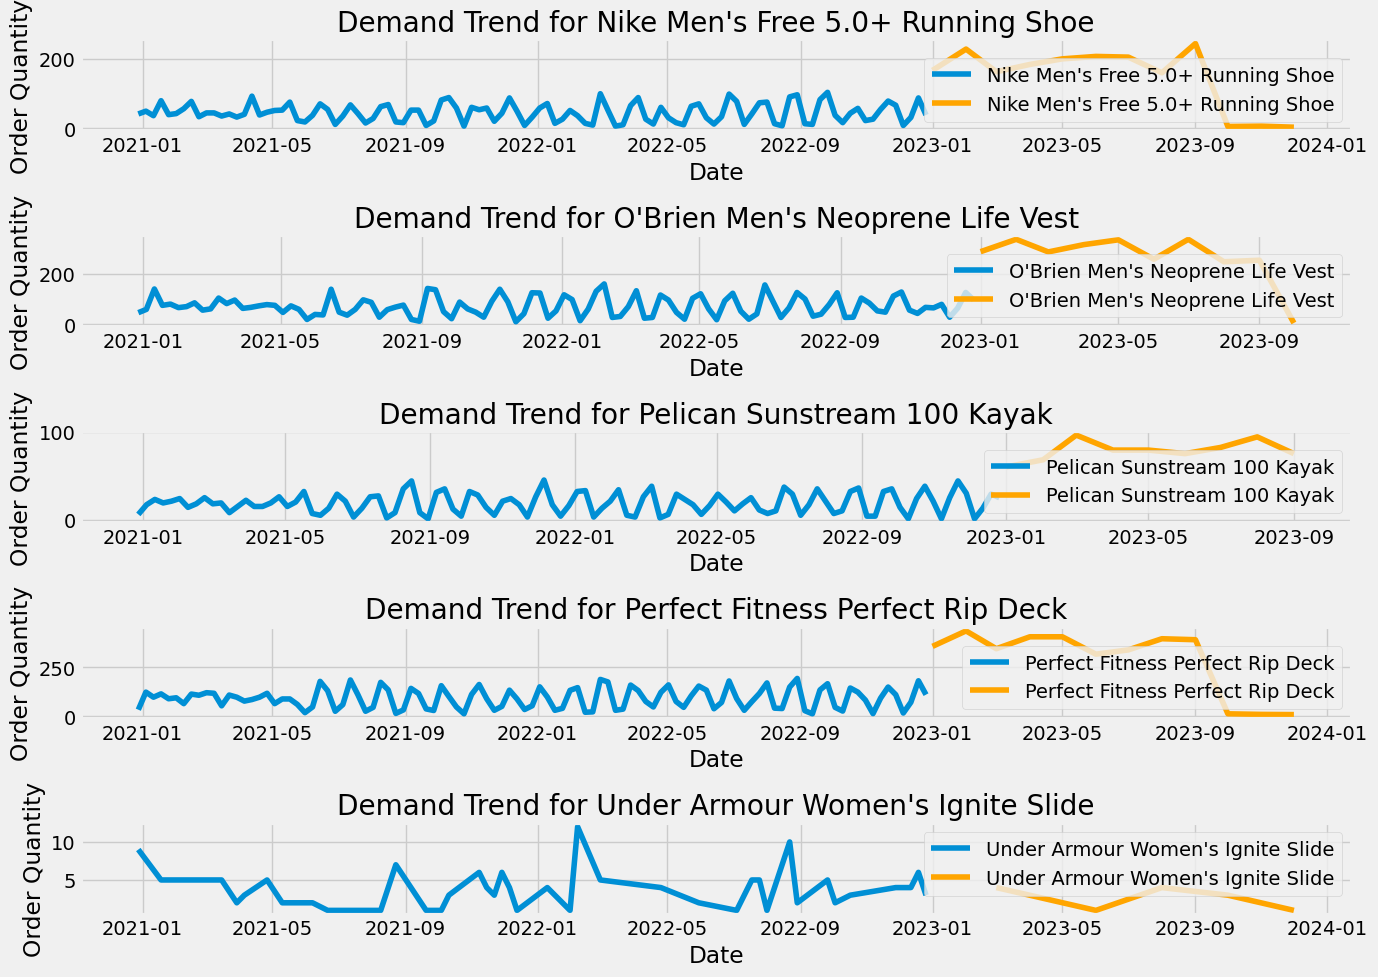

In [1042]:
plt.figure(figsize=(14, 10))

for i in range(5): 
    category = sales_by_week_category['Product Name'].unique()[i]
    
    plt.subplot(5, 1, i+1)
    plt.plot(train_data_week[category]['ds'], train_data_week[category]['y'], label=category)
    plt.plot(test_data_month[category]['ds'], test_data_month[category]['y'], label=category, color = 'orange')
    plt.title(f'Demand Trend for {category}')
    plt.xlabel('Date')
    plt.ylabel('Order Quantity')
    plt.legend()
    plt.tight_layout()
    
plt.show()

## <center>**Prophet Model**

In [1126]:
prophet_weekly_model = dict()

category_name = sales_by_week_category['Product Name'].unique()[i]

product_category = sales_by_week_category[sales_by_week_category['Product Name'] == category_name]['Product Name'].iloc[0] 

seasonality_mode = 'multiplicative' if product_category in ['A', 'B'] else 'additive'

for category in sales_by_week_category['Product Name'].unique():
    model = Prophet(seasonality_mode=seasonality_mode, daily_seasonality=False, weekly_seasonality=True, yearly_seasonality=True, 
                    changepoint_prior_scale=0.5, seasonality_prior_scale=10) 
    model.fit(train_data_week[category])
    prophet_weekly_model[category] = model

14:06:57 - cmdstanpy - INFO - Chain [1] start processing
14:06:57 - cmdstanpy - INFO - Chain [1] done processing
14:06:57 - cmdstanpy - INFO - Chain [1] start processing
14:06:57 - cmdstanpy - INFO - Chain [1] done processing
14:06:57 - cmdstanpy - INFO - Chain [1] start processing
14:06:57 - cmdstanpy - INFO - Chain [1] done processing
14:06:57 - cmdstanpy - INFO - Chain [1] start processing
14:06:57 - cmdstanpy - INFO - Chain [1] done processing
14:06:57 - cmdstanpy - INFO - Chain [1] start processing
14:06:58 - cmdstanpy - INFO - Chain [1] done processing


In [1044]:
prophet_weekly_model

{"Nike Men's Free 5.0+ Running Shoe": <prophet.forecaster.Prophet at 0x148752840>,
 "O'Brien Men's Neoprene Life Vest": <prophet.forecaster.Prophet at 0x14d0c28a0>,
 'Pelican Sunstream 100 Kayak': <prophet.forecaster.Prophet at 0x14d0c1280>,
 'Perfect Fitness Perfect Rip Deck': <prophet.forecaster.Prophet at 0x14c675580>,
 "Under Armour Women's Ignite Slide": <prophet.forecaster.Prophet at 0x149875340>}


=== SKU: Nike Men's Free 5.0+ Running Shoe ===
Mean order qty: 38.26 | Std dev: 34.30
MAE: 32.17, RMSE: 36.81

=== SKU: O'Brien Men's Neoprene Life Vest ===
Mean order qty: 68.28 | Std dev: 41.89
MAE: 37.02, RMSE: 42.49

=== SKU: Pelican Sunstream 100 Kayak ===
Mean order qty: 18.13 | Std dev: 13.51
MAE: 12.49, RMSE: 13.69

=== SKU: Perfect Fitness Perfect Rip Deck ===
Mean order qty: 68.38 | Std dev: 62.45
MAE: 63.60, RMSE: 70.99

=== SKU: Under Armour Women's Ignite Slide ===
Mean order qty: 1.86 | Std dev: 1.21
MAE: 2.78, RMSE: 3.44


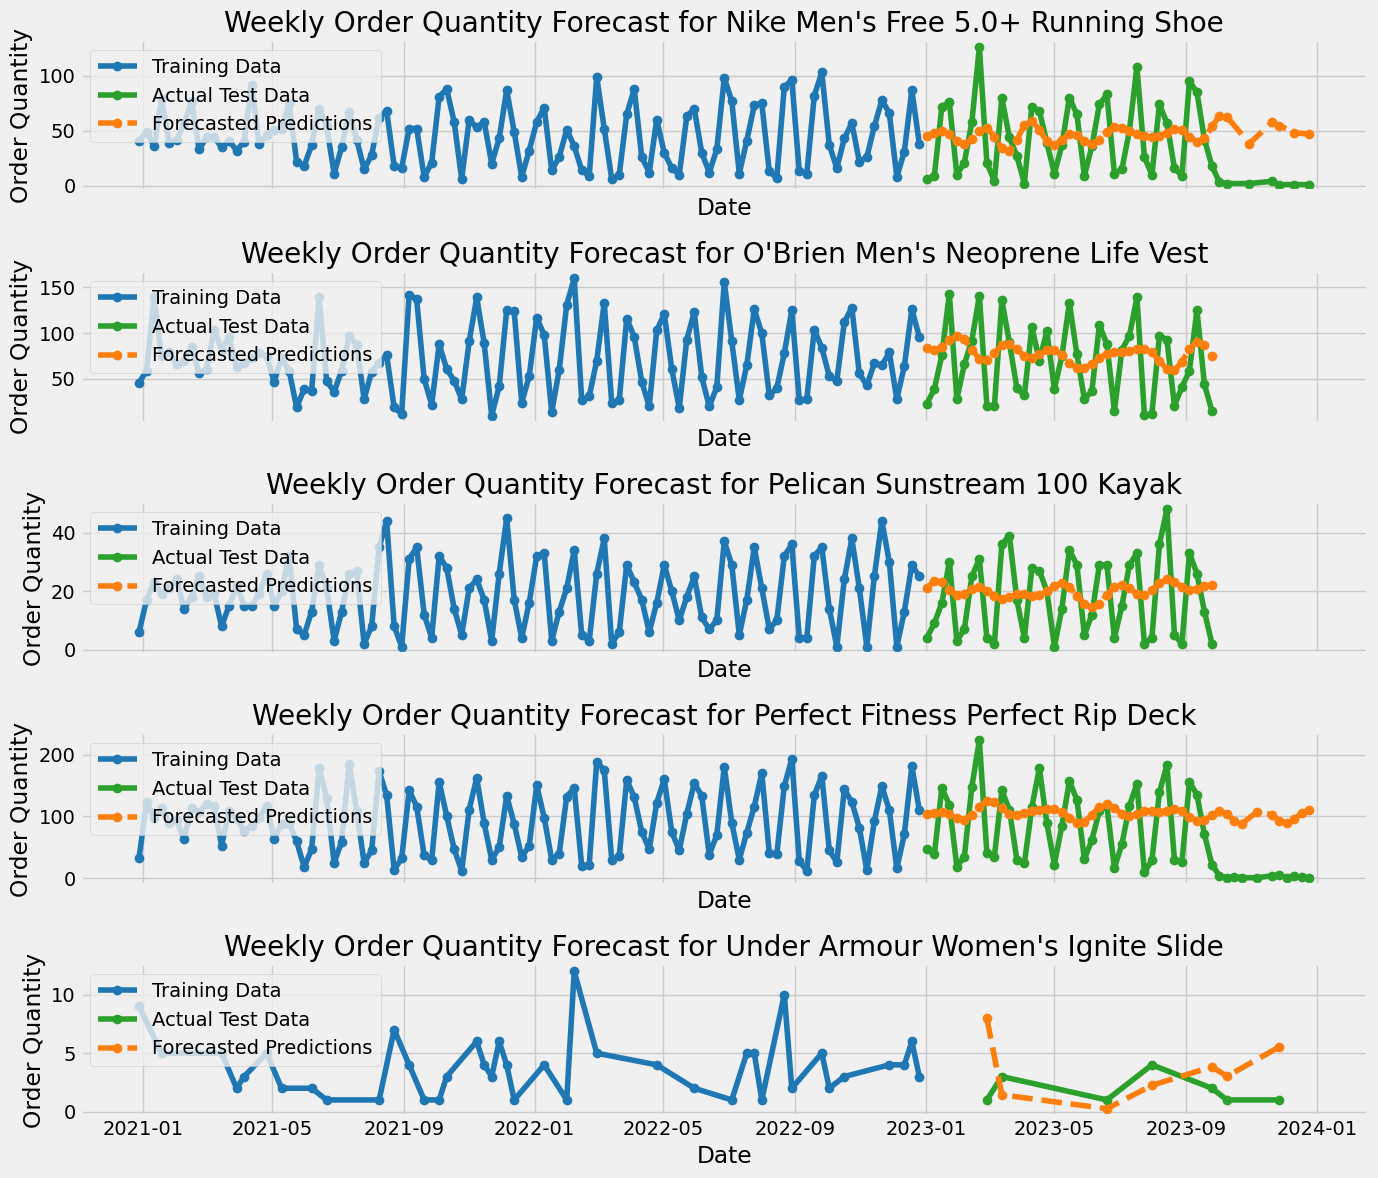

In [ ]:
plt.style.use('fivethirtyeight')

prophet_month_forecast = dict()

products_to_plot = sales_by_week_category['Product Name'].unique()

fig, ax = plt.subplots(len(products_to_plot), 1, figsize=(14, 12), sharex=True)

for i, category_name in enumerate(products_to_plot):

    # Predict on the test data for the current product
    prophet_month_forecast[category_name] = prophet_weekly_model[category_name].predict(test_data_week[category_name])
    
    # Get the model's history 
    model_history = prophet_weekly_model[category_name].history
   
    # Plot the training data
    ax[i].plot(model_history['ds'], model_history['y'], marker='o', linestyle='-', label='Training Data', color='tab:blue')
    
    # Plot the test data
    ax[i].plot(test_data_week[category_name]['ds'], test_data_week[category_name]['y'], marker='o', linestyle='-', label='Actual Test Data', color='tab:green')
    
    # Plot the forecast for the test 
    forecast_for_test = prophet_month_forecast[category_name]
    ax[i].plot(forecast_for_test['ds'], forecast_for_test['yhat'], marker='o', linestyle='--', label='Forecasted Predictions', color='tab:orange')
    
    ax[i].set_title(f'Weekly Order Quantity Forecast for {category_name}')
    ax[i].set_xlabel('Date')
    ax[i].set_ylabel('Order Quantity')
    ax[i].legend(loc='upper left')
    
    # Extract the actual values and predicted values 
    y_true = test_data_week[category_name]['y']
    y_pred = forecast_for_test['yhat']

    # mean and std dev
    mean_qty = y_true.mean()
    std_qty = y_true.std()

    # Calculate the metrics
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    
    # Print the results for the current SKU
    print(f"\n=== SKU: {category_name} ===")
    print(f"Mean order qty: {mean_qty:.2f} | Std dev: {std_qty:.2f}")
    print(f"MAE: {mae:.2f}, RMSE: {rmse:.2f}")
    
    # Store metrics in a dictionary
    models_metrics[category_name] = {'MAE': mae, 'RMSE': rmse, 'R2': r2, 'SMAPE': smape_val}

plt.tight_layout()
plt.show()

#### **Forecasting and Evaluating Monthly using Prophet Model**

In this section, monthly forecasting will be done for each of the product. With monthly forecasts, order quantity can be easily aggregated and the fluctuations with daily and weekly data are lesser.

In [1046]:
sales_by_month_category = df_filtered.copy()

sales_by_month_category['Order Date'] = sales_by_month_category['Order Date'].astype('datetime64[ns]')

sales_by_month_category['Order Date'] = sales_by_month_category['Order Date'].dt.to_period('M')

sales_by_month_category = sales_by_month_category.groupby(['Order Date', 'Product Name'])['Order Quantity'].sum().reset_index()

sales_by_month_category['Order Date'] = sales_by_month_category['Order Date'].dt.to_timestamp()

sales_by_month_category.head(10)

,Order Date,Product Name,Order Quantity
0,2021-01-01,Nike Men's Free 5.0+ Running Shoe,244
1,2021-01-01,O'Brien Men's Neoprene Life Vest,400
2,2021-01-01,Pelican Sunstream 100 Kayak,86
3,2021-01-01,Perfect Fitness Perfect Rip Deck,456
4,2021-01-01,Under Armour Women's Ignite Slide,14
5,2021-02-01,Nike Men's Free 5.0+ Running Shoe,208
6,2021-02-01,O'Brien Men's Neoprene Life Vest,277
7,2021-02-01,Pelican Sunstream 100 Kayak,81
8,2021-02-01,Perfect Fitness Perfect Rip Deck,378
9,2021-03-01,Nike Men's Free 5.0+ Running Shoe,181


In [1047]:
train_data_month = {}
test_data_month = {}

for category in sales_by_month_category['Product Name'].unique():
    category_data_monthly = sales_by_month_category[sales_by_month_category['Product Name'] == category][['Order Date', 'Order Quantity']]
    
    category_data_monthly = category_data_monthly.rename(columns = {'Order Date': 'ds', 'Order Quantity': 'y'})
    
    train_data_month[category] = category_data_monthly[category_data_monthly['ds'].dt.year < 2023]
    test_data_month[category] = category_data_monthly[category_data_monthly['ds'].dt.year >= 2023]

In [1123]:
prophet_weekly_model = dict()

category_name = sales_by_month_category['Product Name'].unique()[i]

product_category = sales_by_month_category[sales_by_month_category['Product Name'] == category_name]['Product Name'].iloc[0] 

seasonality_mode = 'additive'
# 'multiplicative' if product_category in ['A', 'B'] else 'additive'

for category in sales_by_month_category['Product Name'].unique():
    model = Prophet(seasonality_mode=seasonality_mode, daily_seasonality=False, weekly_seasonality=False, yearly_seasonality=True, 
                    changepoint_prior_scale=0.3, seasonality_prior_scale=10) 
    model.fit(train_data_month[category])
    prophet_weekly_model[category] = model

13:59:13 - cmdstanpy - INFO - Chain [1] start processing
13:59:28 - cmdstanpy - INFO - Chain [1] done processing
13:59:28 - cmdstanpy - INFO - Chain [1] start processing
13:59:36 - cmdstanpy - INFO - Chain [1] done processing
13:59:36 - cmdstanpy - INFO - Chain [1] start processing
13:59:50 - cmdstanpy - INFO - Chain [1] done processing
13:59:50 - cmdstanpy - INFO - Chain [1] start processing
14:00:03 - cmdstanpy - INFO - Chain [1] done processing
14:00:03 - cmdstanpy - INFO - Chain [1] start processing
14:00:15 - cmdstanpy - INFO - Chain [1] done processing



=== SKU: Nike Men's Free 5.0+ Running Shoe ===
Mean order qty: 146.92 | Std dev: 89.37
MAE: 93.15, RMSE: 106.10

=== SKU: O'Brien Men's Neoprene Life Vest ===
Mean order qty: 266.50 | Std dev: 98.27
MAE: 114.00, RMSE: 177.01

=== SKU: Pelican Sunstream 100 Kayak ===
Mean order qty: 78.67 | Std dev: 11.38
MAE: 19.02, RMSE: 25.98

=== SKU: Perfect Fitness Perfect Rip Deck ===
Mean order qty: 285.17 | Std dev: 169.44
MAE: 173.26, RMSE: 233.75

=== SKU: Under Armour Women's Ignite Slide ===
Mean order qty: 2.60 | Std dev: 1.52
MAE: 11.72, RMSE: 14.65


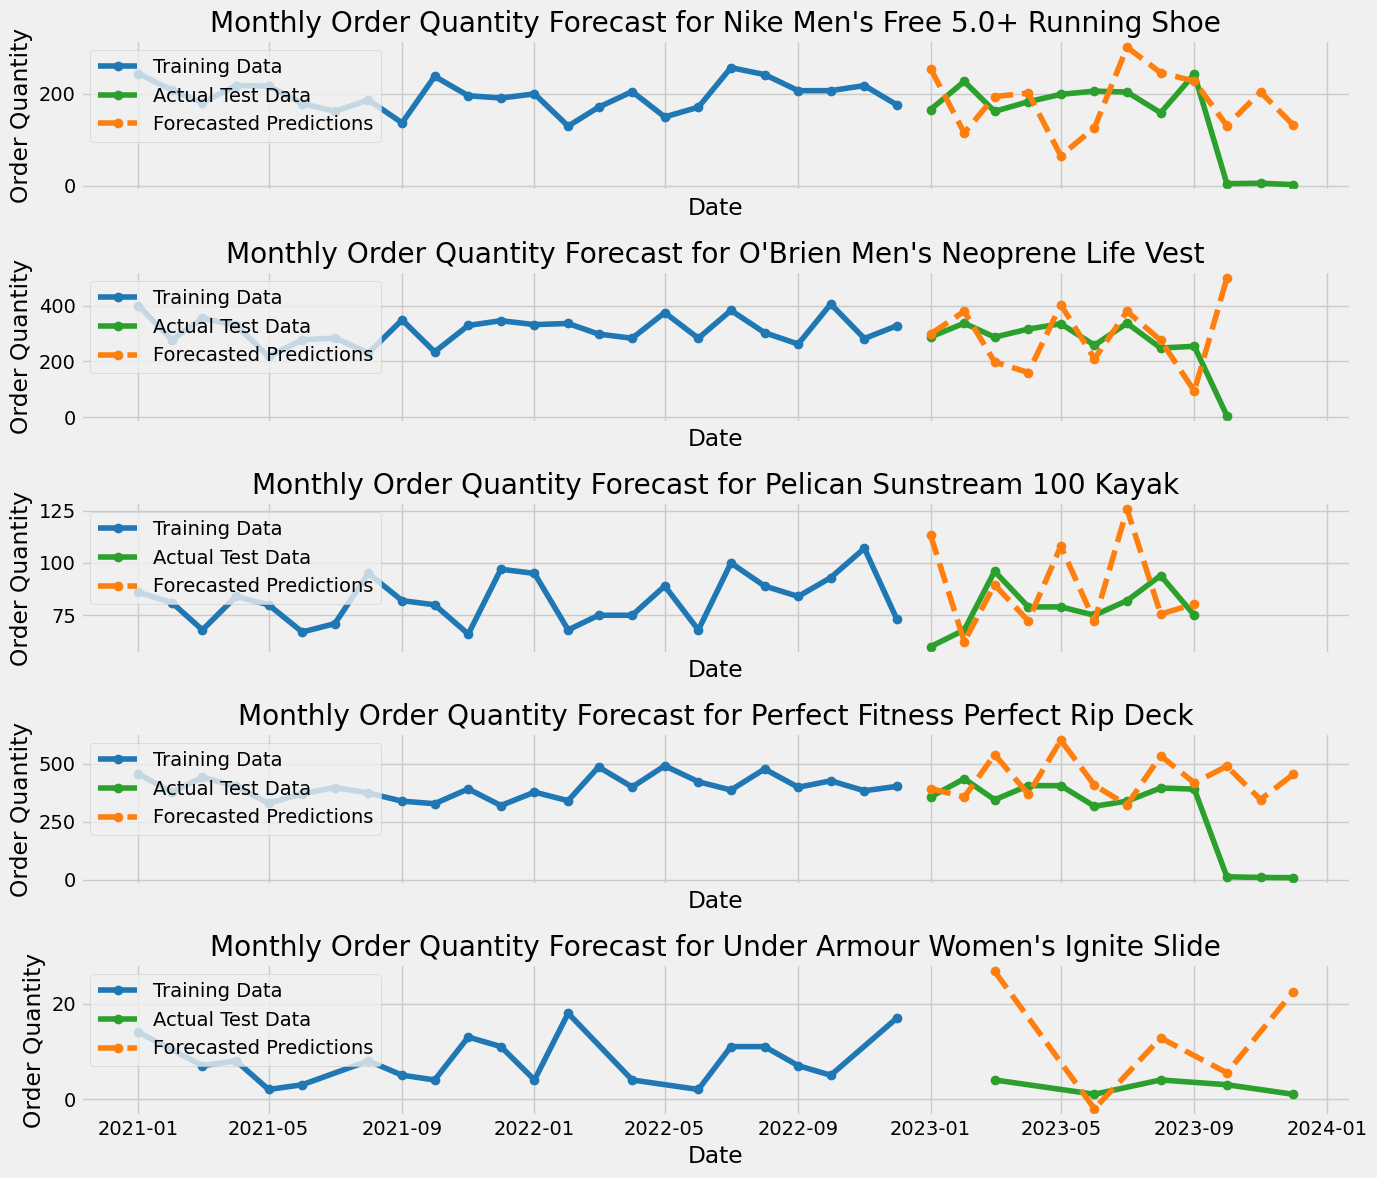

In [ ]:
plt.style.use('fivethirtyeight')

prophet_month_forecast = dict()

products_to_plot = sales_by_month_category['Product Name'].unique()

fig, ax = plt.subplots(len(products_to_plot), 1, figsize=(14, 12), sharex=True)

for i, category_name in enumerate(products_to_plot):

    # Predict on the test data 
    prophet_month_forecast[category_name] = prophet_weekly_model[category_name].predict(test_data_month[category_name])
    
    # Get the model's history 
    model_history = prophet_weekly_model[category_name].history
   
    # Plot the training data
    ax[i].plot(model_history['ds'], model_history['y'], marker='o', linestyle='-', label='Training Data', color='tab:blue')
    
    # Plot the actual test data
    ax[i].plot(test_data_month[category_name]['ds'], test_data_month[category_name]['y'], marker='o', linestyle='-', label='Actual Test Data', color='tab:green')
    
    # Plot the forecast for the test period
    forecast_for_test = prophet_month_forecast[category_name]
    ax[i].plot(forecast_for_test['ds'], forecast_for_test['yhat'], marker='o', linestyle='--', label='Forecasted Predictions', color='tab:orange')
    
    ax[i].set_title(f'Monthly Order Quantity Forecast for {category_name}')
    ax[i].set_xlabel('Date')
    ax[i].set_ylabel('Order Quantity')
    ax[i].legend(loc='upper left')
    
    # Extract the actual values and predicted values 
    y_true = test_data_month[category_name]['y']
    y_pred = forecast_for_test['yhat']

    # mean and std dev
    mean_qty = y_true.mean()
    std_qty = y_true.std()

    # Calculate the metrics
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    
    # Print the results for the current SKU
    print(f"\n=== SKU: {category_name} ===")
    print(f"Mean order qty: {mean_qty:.2f} | Std dev: {std_qty:.2f}")
    print(f"MAE: {mae:.2f}, RMSE: {rmse:.2f}")
    
    # Store metrics in a dictionary
    models_metrics[category_name] = {'MAE': mae, 'RMSE': rmse, 'R2': r2, 'SMAPE': smape_val}


plt.tight_layout()
plt.show()

## <center>**Crostons Method For C Class Product**

In [ ]:
c_product = 'Under Armour Women\'s Ignite Slide'

# Filter the data for the product
c_product_data = df_filtered[df_filtered['Product Name'] == c_product].copy()

# Convert the 'Order Date' column to datetime
c_product_data['Order Date'] = pd.to_datetime(c_product_data['Order Date'])

# Set 'Order Date' as the index
c_product_data.set_index('Order Date', inplace=True)

c_weekly_demand = c_product_data['Order Quantity'].resample('W').sum().fillna(0)

# Separate demand and intervals
non_zero_demands = c_weekly_demand[c_weekly_demand > 0]
intervals = non_zero_demands.index.to_series().diff().dt.days.fillna(0).astype(int) / 7

# Forecast demand size and intervals
alpha = 0.1
forecasted_demand_size = non_zero_demands.ewm(alpha=alpha).mean().iloc[-1]
forecasted_interval = intervals.ewm(alpha=alpha).mean().iloc[-1]

# Combine for the final forecast
croston_forecast = forecasted_demand_size / forecasted_interval

print(f"\nCroston's Method Forecast for {c_product}:")
print(f"Forecasted demand size: {forecasted_demand_size:.2f} units")
print(f"Forecasted interval between sales: {forecasted_interval:.2f} weeks")
print(f"Final average weekly demand forecast (Croston's): {croston_forecast:.2f} units")


Croston's Method Forecast for Under Armour Women's Ignite Slide:
Forecasted demand size: 2.83 units
Forecasted interval between sales: 4.65 weeks
Final average weekly demand forecast (Croston's): 0.61 units


## <center>**Holt Winters**

In [1052]:
df_filtered

,Order Date,Order ID,Order Item ID,Order Quantity,Product Department,Product Category,Product Name,Customer ID,Customer Market,Customer Region,...,Restock Now,Daily Demand Std Dev,Safety Stock,Month,Season,Season Encoded,Customer Market Encoded,Customer Region Encoded,Shipment Mode Encoded,Warehouse Country Encoded
0,2021-01-01,1,4381,1,Fan Shop,Water Sports,Pelican Sunstream 100 Kayak,7399,LATAM,Central America,...,0,1.514742,33.720019,1,Winter,0,2,3,0,0
1,2021-01-01,2,29,1,Apparel,Cleats,Perfect Fitness Perfect Rip Deck,918,LATAM,South America,...,0,1.514742,151.567657,1,Winter,0,2,12,3,1
2,2021-01-01,3,32,4,Footwear,Cardio Equipment,Nike Men's Free 5.0+ Running Shoe,918,LATAM,South America,...,1,1.514742,92.162541,1,Winter,0,2,12,3,1
3,2021-01-01,4,33,5,Fan Shop,Indoor/Outdoor Games,O'Brien Men's Neoprene Life Vest,918,LATAM,South America,...,0,1.514742,96.287752,1,Winter,0,2,12,3,1
4,2021-01-01,5,109801,5,Footwear,Electronics,Under Armour Women's Ignite Slide,6124,Europe,Eastern Europe,...,1,1.514742,16.525510,1,Winter,0,1,8,3,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12566,2023-12-17,30767,73387,1,Apparel,Cleats,Perfect Fitness Perfect Rip Deck,5078,Pacific Asia,Southeast Asia,...,1,0.000000,151.567657,12,Winter,0,4,15,3,0
12567,2023-12-18,30777,74241,1,Apparel,Cleats,Perfect Fitness Perfect Rip Deck,12040,Pacific Asia,Oceania,...,1,0.000000,151.567657,12,Winter,0,4,11,2,0
12568,2023-12-21,30800,64015,1,Apparel,Cleats,Perfect Fitness Perfect Rip Deck,10865,Pacific Asia,Southeast Asia,...,1,0.000000,151.567657,12,Winter,0,4,15,0,0
12569,2023-12-31,30865,58258,1,Apparel,Cleats,Perfect Fitness Perfect Rip Deck,3628,Pacific Asia,Southeast Asia,...,1,0.000000,151.567657,12,Winter,0,4,15,1,0


In [ ]:
df_hw = df_filtered.copy()

# Convert to datetime
df_hw['Order Date'] = pd.to_datetime(df_hw['Order Date'])

# Aggregate for duplicates
df_hw = df_hw.groupby(['Order Date', 'Product Name'], as_index=False)['Order Quantity'].sum()

# set index
# df_hw.set_index('Order Date', inplace=True)

# Apply weekly frequency
product_dfs = {}
for product in df_hw['Product Name'].unique():
    product_data = df_hw[df_hw['Product Name'] == product].copy()
    product_data = product_data.asfreq('W', fill_value=0)  # fill missing weeks
    product_dfs[product] = product_data

unique_products = df_filtered['Product Name'].unique()

In [1054]:
df_hw

,Order Date,Product Name,Order Quantity
0,2021-01-01,Nike Men's Free 5.0+ Running Shoe,18
1,2021-01-01,O'Brien Men's Neoprene Life Vest,15
2,2021-01-01,Pelican Sunstream 100 Kayak,4
3,2021-01-01,Perfect Fitness Perfect Rip Deck,9
4,2021-01-01,Under Armour Women's Ignite Slide,9
...,...,...,...
3212,2023-12-17,Perfect Fitness Perfect Rip Deck,1
3213,2023-12-18,Perfect Fitness Perfect Rip Deck,1
3214,2023-12-21,Perfect Fitness Perfect Rip Deck,1
3215,2023-12-31,Nike Men's Free 5.0+ Running Shoe,1


In [1055]:
df_hw['Product Name'].unique()

array(["Nike Men's Free 5.0+ Running Shoe",
       "O'Brien Men's Neoprene Life Vest", 'Pelican Sunstream 100 Kayak',
       'Perfect Fitness Perfect Rip Deck',
       "Under Armour Women's Ignite Slide"], dtype=object)


--- Modeling for product: Nike Men's Free 5.0+ Running Shoe ---
Using multiplicative seasonal model for category Nike Men's Free 5.0+ Running Shoe.


/Users/macintosh/Desktop/Dissertation/Smart-Inventory-Replenishment-System-for-E-Commerce/bevisvenv/lib/python3.12/site-packages/statsmodels/tsa/holtwinters/model.py:903: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(


Training Set Context -> Mean Demand: 44.78, Std Dev: 26.3
Holt-Winters Mean Absolute Error (MAE): 36.41
Holt-Winters Root Mean Squared Error (RMSE): 41.84


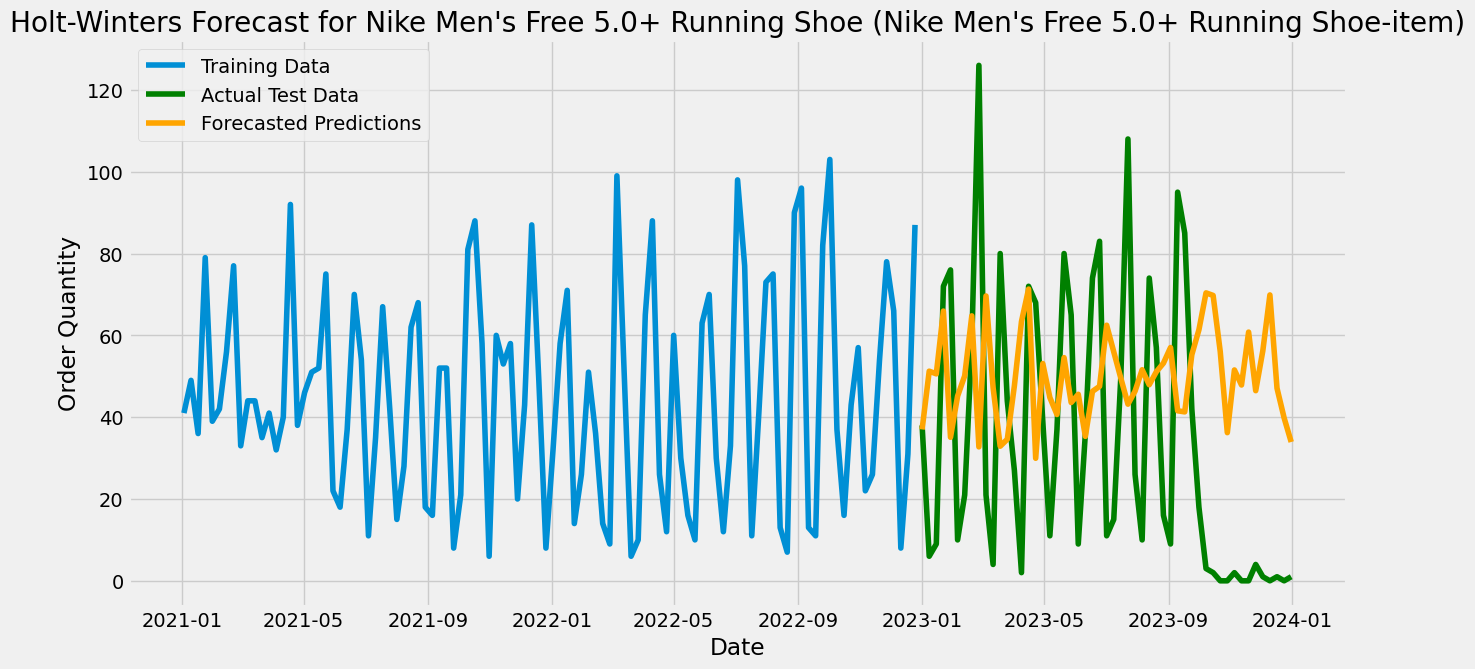


--- Modeling for product: O'Brien Men's Neoprene Life Vest ---
Using multiplicative seasonal model for category O'Brien Men's Neoprene Life Vest.
Training Set Context -> Mean Demand: 71.2, Std Dev: 37.78
Holt-Winters Mean Absolute Error (MAE): 58.4
Holt-Winters Root Mean Squared Error (RMSE): 66.03


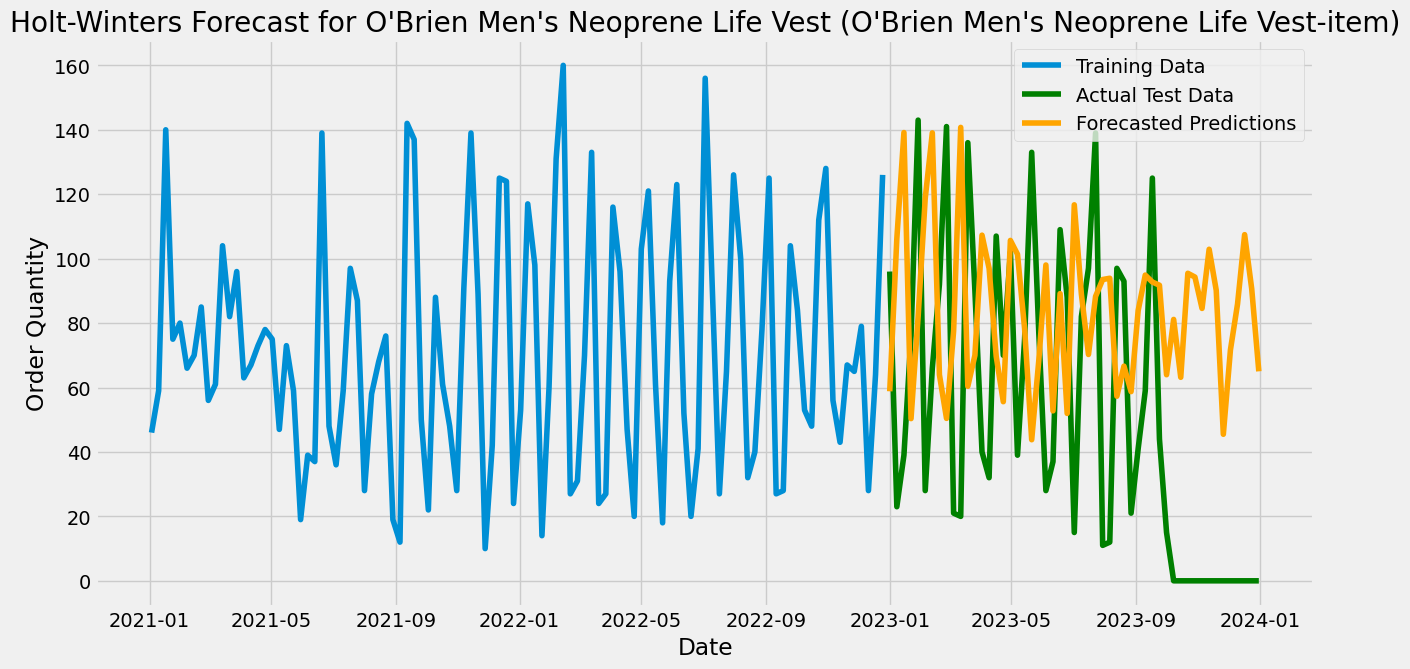


--- Modeling for product: Pelican Sunstream 100 Kayak ---
Using multiplicative seasonal model for category Pelican Sunstream 100 Kayak.


/Users/macintosh/Desktop/Dissertation/Smart-Inventory-Replenishment-System-for-E-Commerce/bevisvenv/lib/python3.12/site-packages/statsmodels/tsa/holtwinters/model.py:903: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(


Training Set Context -> Mean Demand: 18.74, Std Dev: 11.43
Holt-Winters Mean Absolute Error (MAE): 12.76
Holt-Winters Root Mean Squared Error (RMSE): 15.62


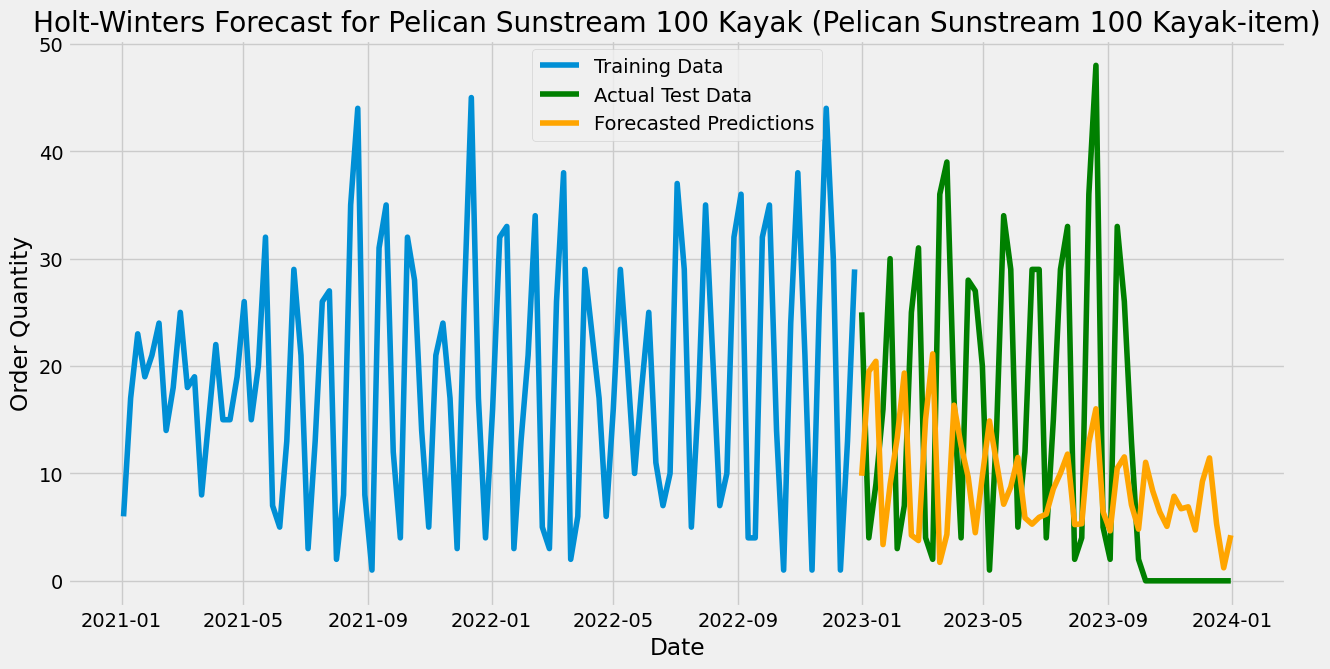


--- Modeling for product: Perfect Fitness Perfect Rip Deck ---
Using multiplicative seasonal model for category Perfect Fitness Perfect Rip Deck.
Training Set Context -> Mean Demand: 90.61, Std Dev: 51.24
Holt-Winters Mean Absolute Error (MAE): 81.86
Holt-Winters Root Mean Squared Error (RMSE): 91.31


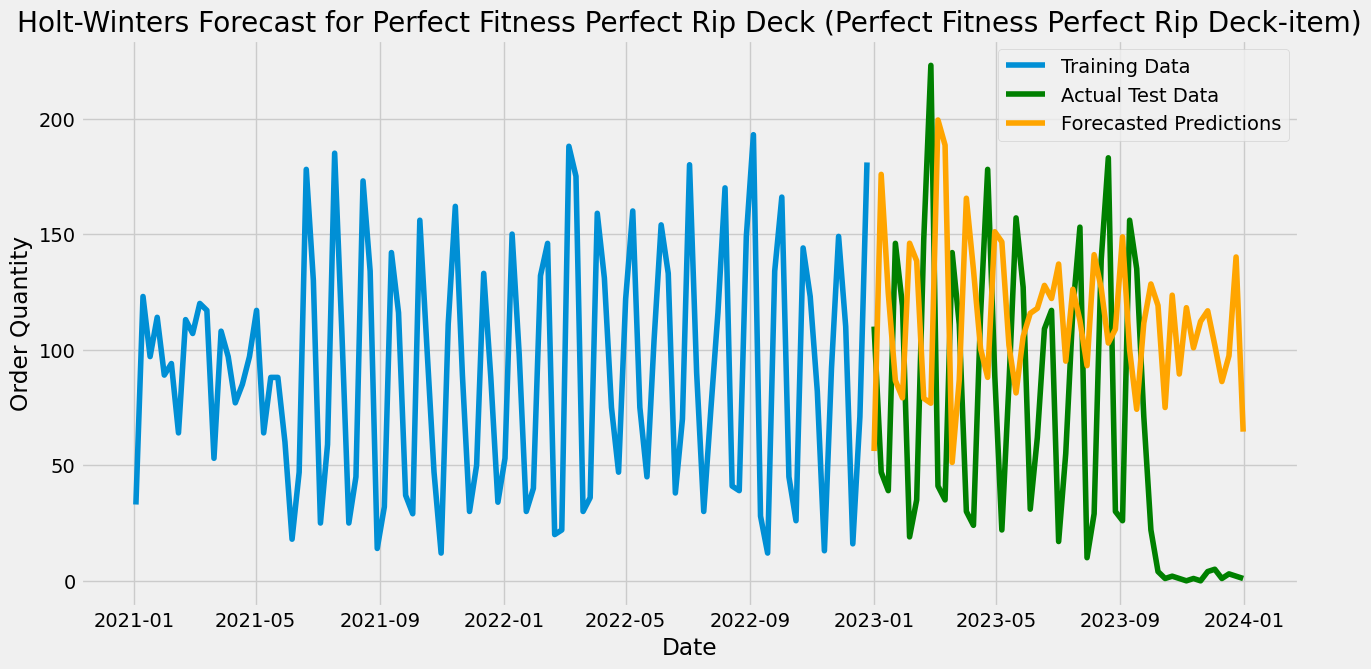


--- Modeling for product: Under Armour Women's Ignite Slide ---
Using additive seasonal model for category Under Armour Women's Ignite Slide.
Training Set Context -> Mean Demand: 1.45, Std Dev: 2.45
Holt-Winters Mean Absolute Error (MAE): 1.4
Holt-Winters Root Mean Squared Error (RMSE): 2.22


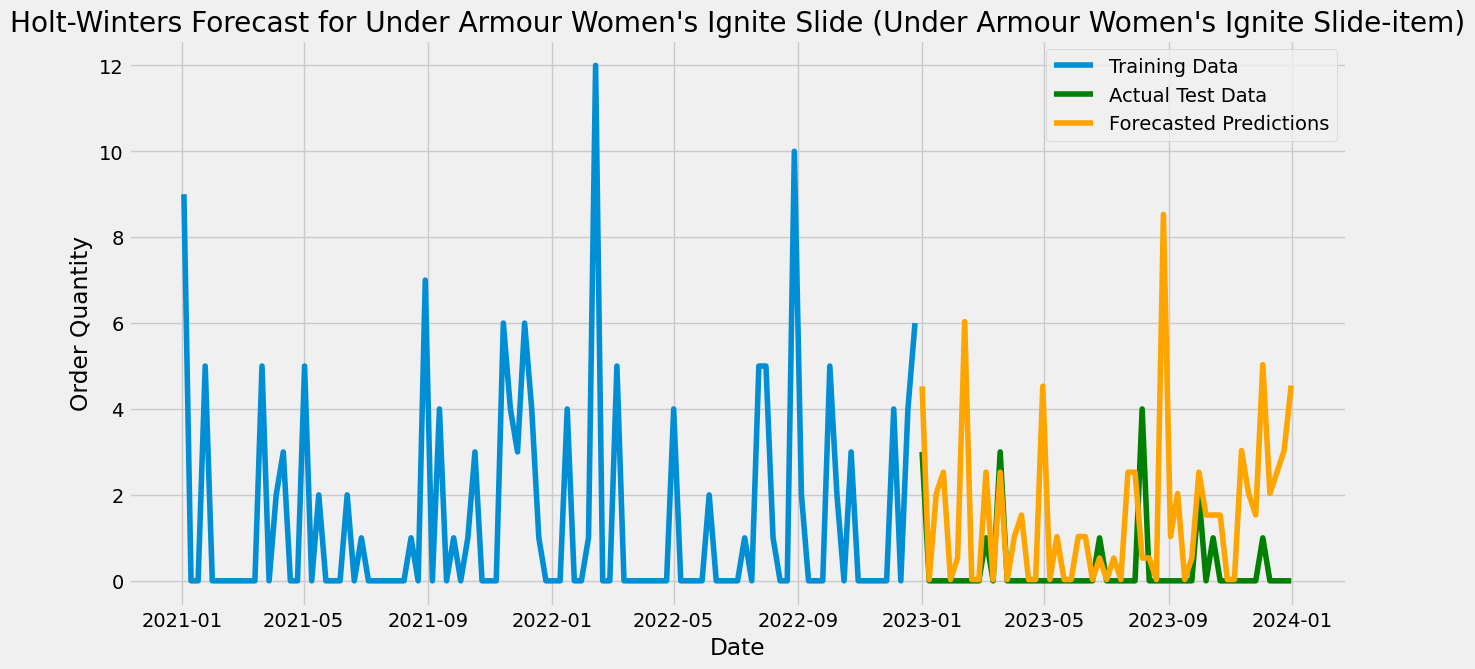


Modeling complete for all products.


In [ ]:
unique_products = df_hw['Product Name'].unique()

# Loop through each product
for product_to_model in unique_products:

    print(f"\n--- Modeling for product: {product_to_model} ---")
    
    # Filter the data for a single product 
    product_data = df_hw[df_hw['Product Name'] == product_to_model].copy()
    product_data.set_index('Order Date', inplace=True)
    product_data.index = pd.to_datetime(product_data.index)
    
    # Find the min and max dates
    global_start_date = df_hw['Order Date'].min()
    global_end_date = df_hw['Order Date'].max()
    
    # Resample the product data to the full date range
    ts_data = product_data['Order Quantity'].resample('W').sum().reindex(
        pd.date_range(start=global_start_date, end=global_end_date, freq='W')
    ).fillna(0)

    # Check for enough data
    if len(ts_data) < 52 * 2: 
        print(f"Skipping {product_to_model}: Insufficient data for Holt-Winters model.")
        continue

    product_category = product_data['Product Name'].iloc[0]
    
    # Split the Data 
    train_start = '2021-01-01'
    train_end = '2022-12-31'
    test_start = '2023-01-01'
    test_end = '2023-12-31'
    
    train_ts = ts_data.loc[train_start:train_end]
    test_ts = ts_data.loc[test_start:test_end]

    # Initialize and Fit the Model 
    multiplicative_products = [
        "Nike Men's Free 5.0+ Running Shoe",
        "O'Brien Men's Neoprene Life Vest",
        'Pelican Sunstream 100 Kayak',
        'Perfect Fitness Perfect Rip Deck'
    ]
    
    seasonal_model = 'multiplicative' if product_to_model in multiplicative_products else 'additive'
    
    print(f"Using {seasonal_model} seasonal model for category {product_category}.")

    holt_winters_model = ExponentialSmoothing(
        train_ts,
        trend='add',
        seasonal=seasonal_model,
        seasonal_periods=52
    )

    # Fit the model to the training data
    hw_fit = holt_winters_model.fit()

    # Predict and Evaluate 
    forecast_hw = hw_fit.forecast(len(test_ts))

    # Evaluate the model
    mae_hw = mean_absolute_error(test_ts, forecast_hw)
    rmse_hw = np.sqrt(mean_squared_error(test_ts, forecast_hw))
    mean_demand = train_ts.mean()
    std_demand = train_ts.std()
    
    print(f"Training Set Context -> Mean Demand: {round(mean_demand,2)}, Std Dev: {round(std_demand,2)}")

    print(f"Holt-Winters Mean Absolute Error (MAE): {round(mae_hw, 2)}")
    print(f"Holt-Winters Root Mean Squared Error (RMSE): {round(rmse_hw, 2)}")
   

    # Step 6: Visualize the Results 
    plt.figure(figsize=(14, 7))
    plt.plot(train_ts.index, train_ts, label='Training Data')
    plt.plot(test_ts.index, test_ts, label='Actual Test Data', color='green')
    plt.plot(forecast_hw.index, forecast_hw, label='Forecasted Predictions', color='orange')
    plt.title(f'Holt-Winters Forecast for {product_to_model} ({product_category}-item)')
    plt.xlabel('Date')
    plt.ylabel('Order Quantity')
    plt.legend()
    plt.show()

print("\nModeling complete for all products.")

In [ ]:
trend_options = ['add', 'mul']
seasonal_options = ['add', 'mul']
seasonal_periods_options = [52]  
alpha_options = [0.2, 0.5, 0.8]  

param_grid = list(itertools.product(trend_options, seasonal_options, seasonal_periods_options, alpha_options))

best_params = {}
best_scores = {}

for product_to_model in unique_products:
    print(f"\nTuning for {product_to_model}...")
    
    # Prepare data 
    product_data = df_hw[df_hw['Product Name'] == product_to_model].copy()
    product_data.set_index('Order Date', inplace=True)
    product_data.index = pd.to_datetime(product_data.index)
    
    global_start_date = df_hw['Order Date'].min()
    global_end_date = df_hw['Order Date'].max()
    
    ts_data = product_data['Order Quantity'].resample('W').sum().reindex(
        pd.date_range(start=global_start_date, end=global_end_date, freq='W')
    ).fillna(0)

    if len(ts_data) < 52 * 2:
        print(f"Skipping {product_to_model}: Not enough data.")
        continue

    train_ts = ts_data.loc['2021-01-01':'2022-12-31']
    test_ts = ts_data.loc['2023-01-01':'2023-12-31']
    
    best_rmse = float("inf")
    best_config = None

    for trend, seasonal, seasonal_periods, alpha in param_grid:
        try:
            model = ExponentialSmoothing(
                train_ts,
                trend=trend,
                seasonal=seasonal,
                seasonal_periods=seasonal_periods
            )
            fit = model.fit(smoothing_level=alpha,
                            smoothing_trend=0.05,
                            smoothing_seasonal=None,
                            optimized=True)
            forecast = fit.forecast(len(test_ts))
            rmse = np.sqrt(mean_squared_error(test_ts, forecast))
            
            if rmse < best_rmse:
                best_rmse = rmse
                best_config = (trend, seasonal, seasonal_periods, alpha)
        except:
            continue 
    
    best_params[product_to_model] = best_config
    best_scores[product_to_model] = best_rmse
    
    print(f"Best for {product_to_model}: {best_config} with RMSE={best_rmse:.2f}")


Tuning for Nike Men's Free 5.0+ Running Shoe...


/Users/macintosh/Desktop/Dissertation/Smart-Inventory-Replenishment-System-for-E-Commerce/bevisvenv/lib/python3.12/site-packages/statsmodels/tsa/holtwinters/model.py:903: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(
/Users/macintosh/Desktop/Dissertation/Smart-Inventory-Replenishment-System-for-E-Commerce/bevisvenv/lib/python3.12/site-packages/statsmodels/tsa/holtwinters/model.py:85: RuntimeWarning: overflow encountered in matmul
  return err.T @ err
/Users/macintosh/Desktop/Dissertation/Smart-Inventory-Replenishment-System-for-E-Commerce/bevisvenv/lib/python3.12/site-packages/statsmodels/tsa/holtwinters/model.py:903: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(
/Users/macintosh/Desktop/Dissertation/Smart-Inventory-Replenishment-System-for-E-Commerce/bevisvenv/lib/python3.12/site-packages/statsmodels/tsa/holtwinters/model.py:903: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.

Best for Nike Men's Free 5.0+ Running Shoe: ('add', 'add', 52, 0.2) with RMSE=45.44

Tuning for O'Brien Men's Neoprene Life Vest...


/Users/macintosh/Desktop/Dissertation/Smart-Inventory-Replenishment-System-for-E-Commerce/bevisvenv/lib/python3.12/site-packages/statsmodels/tsa/holtwinters/model.py:903: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(
/Users/macintosh/Desktop/Dissertation/Smart-Inventory-Replenishment-System-for-E-Commerce/bevisvenv/lib/python3.12/site-packages/statsmodels/tsa/holtwinters/model.py:903: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(
/Users/macintosh/Desktop/Dissertation/Smart-Inventory-Replenishment-System-for-E-Commerce/bevisvenv/lib/python3.12/site-packages/statsmodels/tsa/holtwinters/model.py:903: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(


Best for O'Brien Men's Neoprene Life Vest: ('add', 'add', 52, 0.2) with RMSE=58.47

Tuning for Pelican Sunstream 100 Kayak...


/Users/macintosh/Desktop/Dissertation/Smart-Inventory-Replenishment-System-for-E-Commerce/bevisvenv/lib/python3.12/site-packages/statsmodels/tsa/holtwinters/model.py:903: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(
/Users/macintosh/Desktop/Dissertation/Smart-Inventory-Replenishment-System-for-E-Commerce/bevisvenv/lib/python3.12/site-packages/statsmodels/tsa/holtwinters/model.py:903: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(
/Users/macintosh/Desktop/Dissertation/Smart-Inventory-Replenishment-System-for-E-Commerce/bevisvenv/lib/python3.12/site-packages/statsmodels/tsa/holtwinters/model.py:903: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(
/Users/macintosh/Desktop/Dissertation/Smart-Inventory-Replenishment-System-for-E-Commerce/bevisvenv/lib/python3.12/site-packages/statsmodels/tsa/holtwinters/model.py:903: ConvergenceWarning: Optimization failed to conver

Best for Pelican Sunstream 100 Kayak: ('add', 'add', 52, 0.2) with RMSE=19.30

Tuning for Perfect Fitness Perfect Rip Deck...


/Users/macintosh/Desktop/Dissertation/Smart-Inventory-Replenishment-System-for-E-Commerce/bevisvenv/lib/python3.12/site-packages/statsmodels/tsa/holtwinters/model.py:903: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(
/Users/macintosh/Desktop/Dissertation/Smart-Inventory-Replenishment-System-for-E-Commerce/bevisvenv/lib/python3.12/site-packages/statsmodels/tsa/holtwinters/model.py:903: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(
/Users/macintosh/Desktop/Dissertation/Smart-Inventory-Replenishment-System-for-E-Commerce/bevisvenv/lib/python3.12/site-packages/statsmodels/tsa/holtwinters/model.py:85: RuntimeWarning: overflow encountered in matmul
  return err.T @ err
/Users/macintosh/Desktop/Dissertation/Smart-Inventory-Replenishment-System-for-E-Commerce/bevisvenv/lib/python3.12/site-packages/statsmodels/tsa/holtwinters/model.py:903: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.

Best for Perfect Fitness Perfect Rip Deck: ('add', 'add', 52, 0.2) with RMSE=94.71

Tuning for Under Armour Women's Ignite Slide...
Best for Under Armour Women's Ignite Slide: ('add', 'add', 52, 0.2) with RMSE=2.07



--- Re-plotting Nike Men's Free 5.0+ Running Shoe with best params ---
Trend: add, Seasonal: add, Periods: 52, Alpha: 0.2
Training Set Context -> Mean Demand: 44.78, Std Dev: 26.3
Holt-Winters Mean Absolute Error (MAE): 38.57
Holt-Winters Root Mean Squared Error (RMSE): 43.23


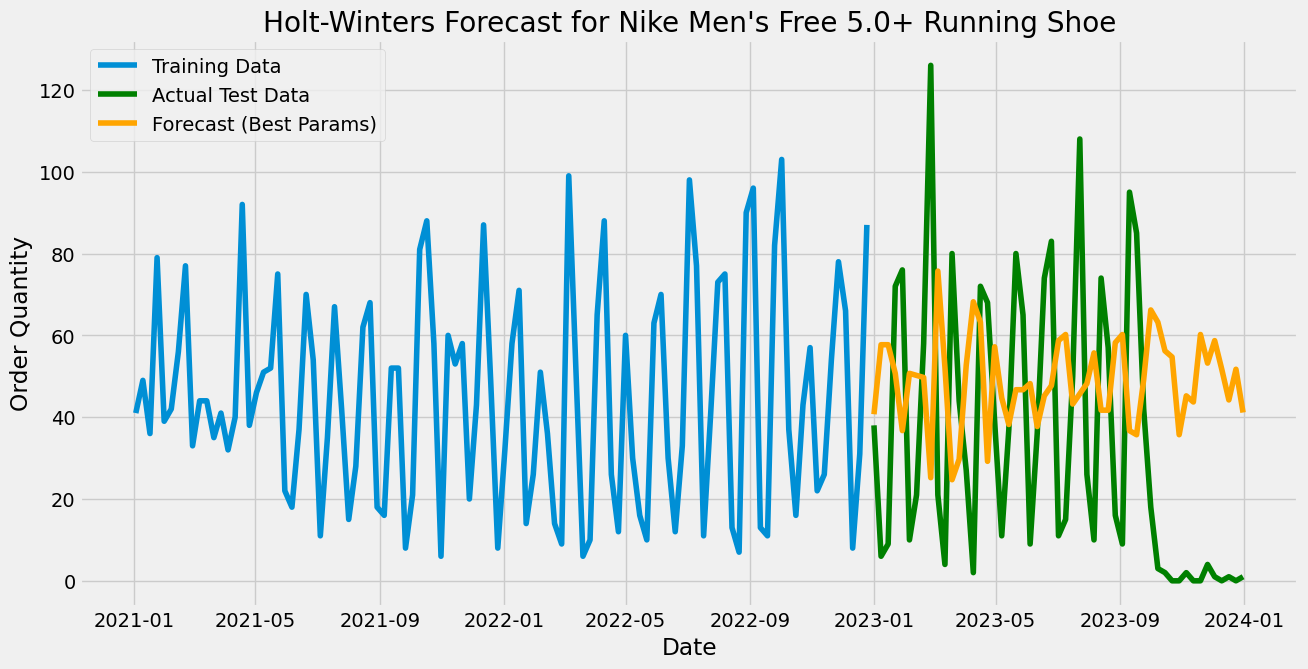


--- Re-plotting O'Brien Men's Neoprene Life Vest with best params ---
Trend: add, Seasonal: add, Periods: 52, Alpha: 0.2
Training Set Context -> Mean Demand: 71.2, Std Dev: 37.78
Holt-Winters Mean Absolute Error (MAE): 53.91
Holt-Winters Root Mean Squared Error (RMSE): 60.14


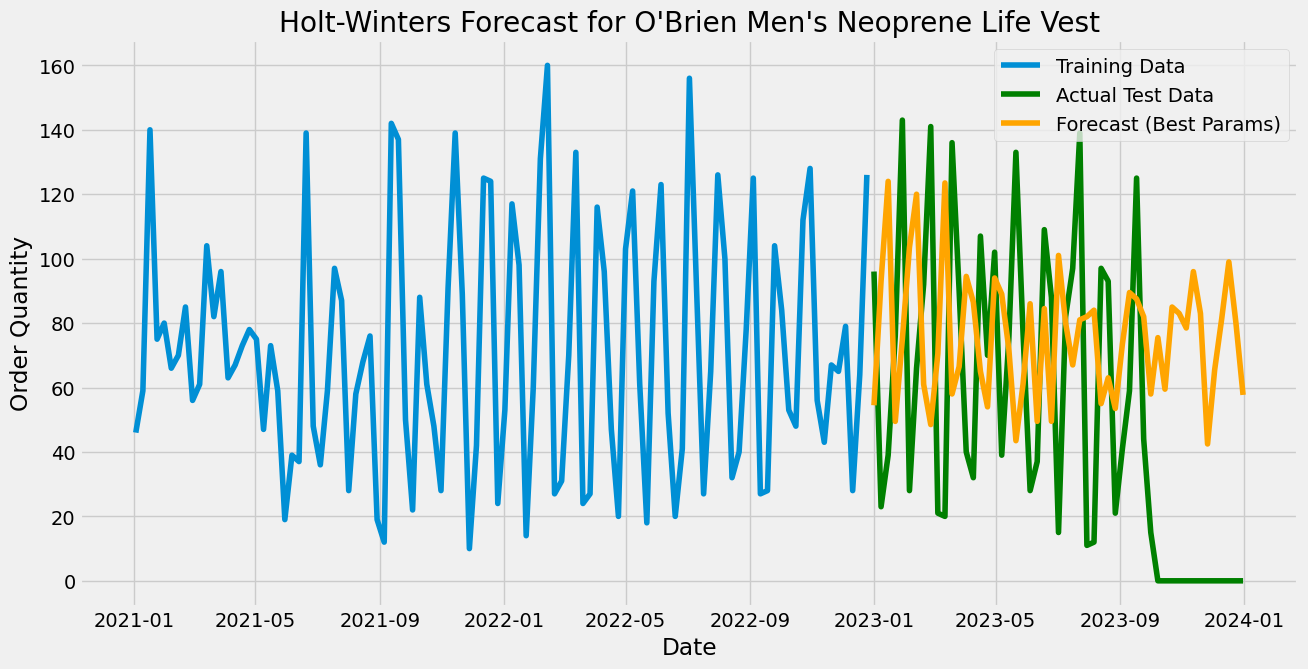


--- Re-plotting Pelican Sunstream 100 Kayak with best params ---
Trend: add, Seasonal: add, Periods: 52, Alpha: 0.2
Training Set Context -> Mean Demand: 18.74, Std Dev: 11.43
Holt-Winters Mean Absolute Error (MAE): 16.84
Holt-Winters Root Mean Squared Error (RMSE): 18.59


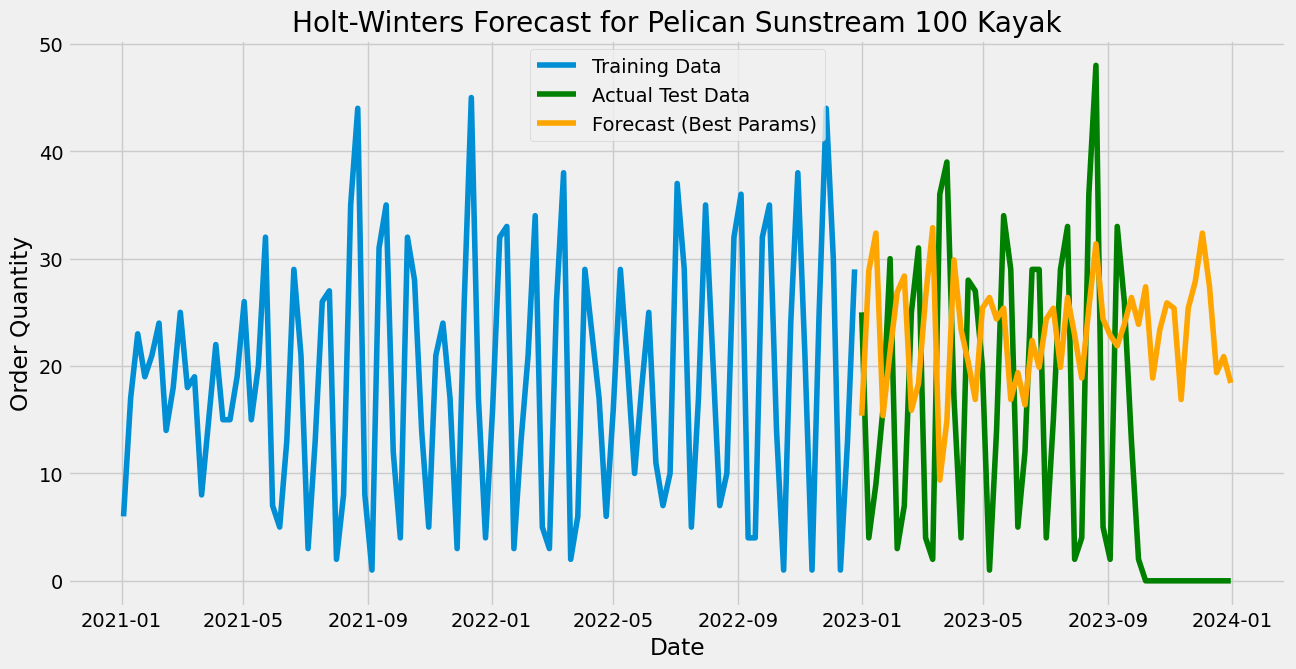


--- Re-plotting Perfect Fitness Perfect Rip Deck with best params ---
Trend: add, Seasonal: add, Periods: 52, Alpha: 0.2
Training Set Context -> Mean Demand: 90.61, Std Dev: 51.24
Holt-Winters Mean Absolute Error (MAE): 77.26
Holt-Winters Root Mean Squared Error (RMSE): 86.06


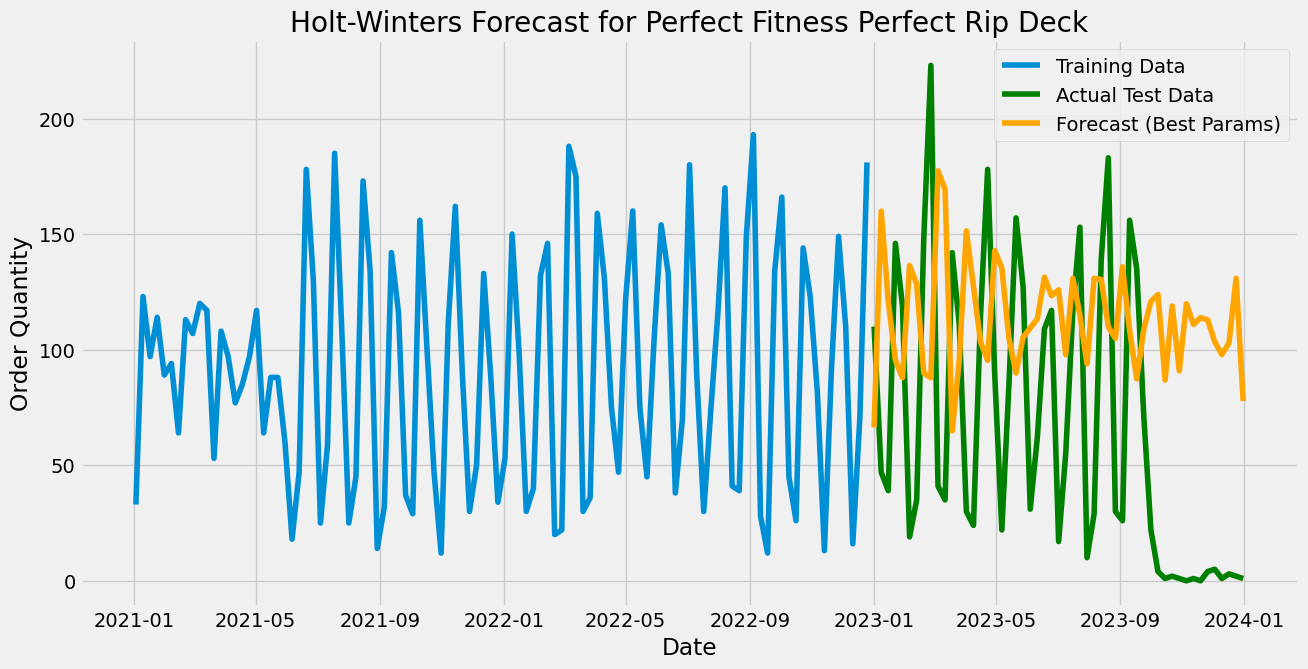


--- Re-plotting Under Armour Women's Ignite Slide with best params ---
Trend: add, Seasonal: add, Periods: 52, Alpha: 0.2
Training Set Context -> Mean Demand: 1.45, Std Dev: 2.45
Holt-Winters Mean Absolute Error (MAE): 1.3
Holt-Winters Root Mean Squared Error (RMSE): 2.03


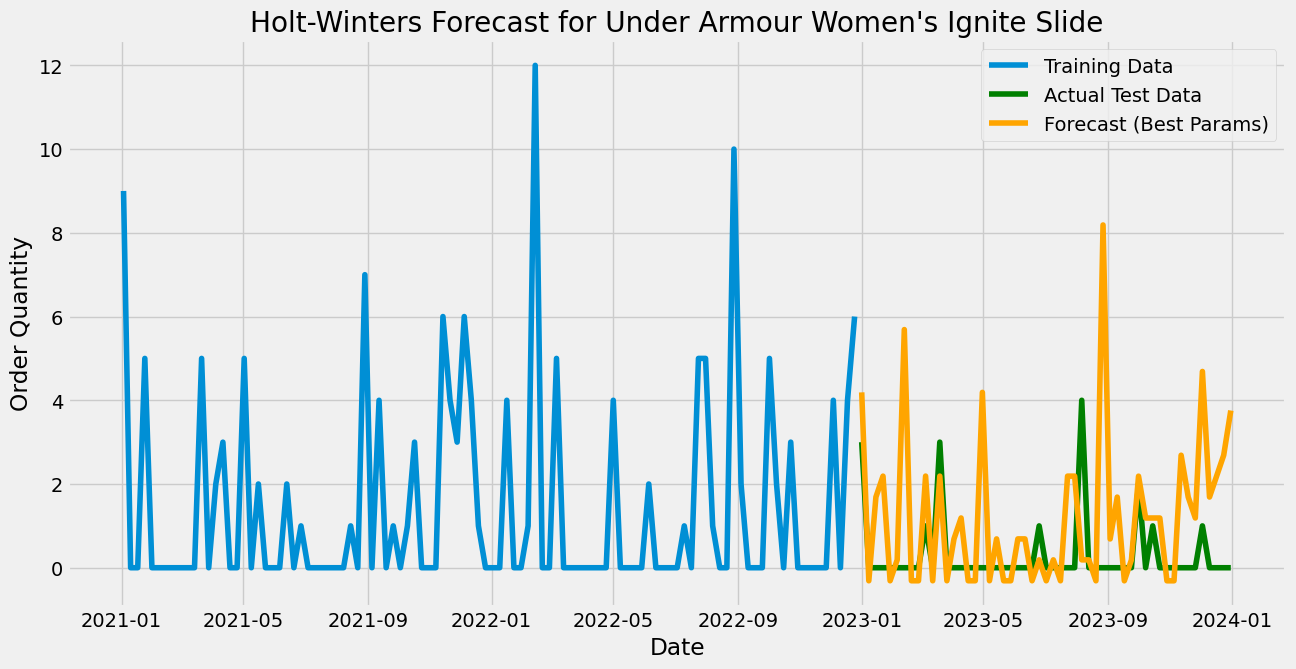

In [ ]:
for product_to_model in unique_products:
    if product_to_model not in best_params:
        print(f"Skipping {product_to_model} — no tuned parameters found.")
        continue

    # best parameters
    trend, seasonal, seasonal_periods, alpha = best_params[product_to_model]
    print(f"\n--- Re-plotting {product_to_model} with best params ---")
    print(f"Trend: {trend}, Seasonal: {seasonal}, Periods: {seasonal_periods}, Alpha: {alpha}")

    # Prepare the product's time series 
    product_data = df_hw[df_hw['Product Name'] == product_to_model].copy()
    product_data.set_index('Order Date', inplace=True)
    product_data.index = pd.to_datetime(product_data.index)

    global_start_date = df_hw['Order Date'].min()
    global_end_date = df_hw['Order Date'].max()

    ts_data = product_data['Order Quantity'].resample('W').sum().reindex(
        pd.date_range(start=global_start_date, end=global_end_date, freq='W')
    ).fillna(0)

    train_ts = ts_data.loc['2021-01-01':'2022-12-31']
    test_ts = ts_data.loc['2023-01-01':'2023-12-31']

    # Fit with best parameters
    model = ExponentialSmoothing(
        train_ts,
        trend=trend,
        seasonal=seasonal,
        seasonal_periods=52
    )
    fit = fit = model.fit(
        smoothing_level=alpha,
        smoothing_trend=best_params.get('beta', None),
        smoothing_seasonal=best_params.get('gamma', None),
        optimized=True  
    )
    forecast = fit.forecast(len(test_ts))
    
    # Evaluate the model
    mae_hw = mean_absolute_error(test_ts, forecast)
    rmse_hw = np.sqrt(mean_squared_error(test_ts, forecast))
    mean_demand = train_ts.mean()
    std_demand = train_ts.std()
    
    print(f"Training Set Context -> Mean Demand: {round(mean_demand,2)}, Std Dev: {round(std_demand,2)}")

    print(f"Holt-Winters Mean Absolute Error (MAE): {round(mae_hw, 2)}")
    print(f"Holt-Winters Root Mean Squared Error (RMSE): {round(rmse_hw, 2)}")

    # Plot
    plt.figure(figsize=(14, 7))
    plt.plot(train_ts.index, train_ts, label='Training Data')
    plt.plot(test_ts.index, test_ts, label='Actual Test Data', color='green')
    plt.plot(forecast.index, forecast, label='Forecast (Best Params)', color='orange')
    plt.title(f'Holt-Winters Forecast for {product_to_model}')
    plt.xlabel('Date')
    plt.ylabel('Order Quantity')
    plt.legend()
    plt.show()

## <center>**XGBoost Regressor Model**

In [ ]:
df_filtered['Order Date'] = pd.to_datetime(df_filtered['Order Date'])
df_filtered['Order Date Copy'] = df_filtered['Order Date']
df_filtered['Order Date Copy'] = pd.to_datetime(df_filtered['Order Date Copy'])

df_filtered.set_index('Order Date', inplace=True)

# Resample to weekly demand and fill missing weeks with 0
weekly_demand_df = df_filtered.groupby(
    ['Product Name', pd.Grouper(level='Order Date', freq='W')]
).agg(
    y=('Order Quantity', 'sum'),                  
    weekly_gross_sales=('Gross Sales', 'sum'),    
    weekly_profit=('Profit', 'sum'),              
    weekly_avg_discount=('Discount %', 'mean'), 
    weekly_avg_ship_days=('Shipment Days - Scheduled', 'mean'),
    weekly_market=('Customer Market Encoded', lambda x: x.mode()[0]),  
    weekly_region=('Customer Region Encoded', lambda x: x.mode()[0]),
    weekly_season=('Season Encoded', lambda x: x.mode()[0]),
    weekly_shipment_mode=('Shipment Mode Encoded', lambda x: x.mode()[0]),
    weekly_warehouse_country=('Warehouse Country Encoded', lambda x: x.mode()[0])
).reset_index()
weekly_demand_df.set_index('Order Date', inplace=True)
weekly_demand_df.rename(columns={'Order Quantity': 'y'}, inplace=True)

# Create Lag and Rolling Window Features
weekly_demand_df['lag_1_week_demand'] = weekly_demand_df.groupby('Product Name')['y'].shift(1)
weekly_demand_df['lag_2_week_demand'] = weekly_demand_df.groupby('Product Name')['y'].shift(2)
weekly_demand_df['lag_3_week_demand'] = weekly_demand_df.groupby('Product Name')['y'].shift(3)
weekly_demand_df['lag_4_week_demand'] = weekly_demand_df.groupby('Product Name')['y'].shift(4)

# fill null values created by shifting
weekly_demand_df.fillna(0, inplace=True)

# Add other known features 
weekly_demand_df['month'] = weekly_demand_df.index.month
weekly_demand_df['week_of_year'] = weekly_demand_df.index.isocalendar().week

                     Feature  MI Score
0         weekly_gross_sales  2.597423
1              weekly_profit  1.699597
12         lag_4_week_demand  0.644294
3       weekly_avg_ship_days  0.288040
10         lag_2_week_demand  0.241896
9          lag_1_week_demand  0.211326
11         lag_3_week_demand  0.131418
2        weekly_avg_discount  0.120032
7       weekly_shipment_mode  0.110832
4              weekly_market  0.039100
8   weekly_warehouse_country  0.025982
13                     month  0.008409
5              weekly_region  0.000000
6              weekly_season  0.000000
14              week_of_year  0.000000


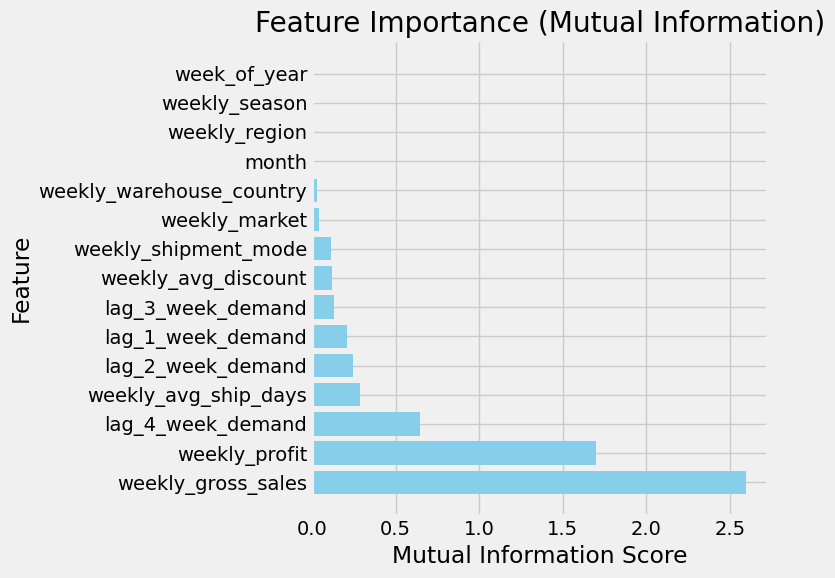

In [ ]:
# Separate features and target
X_mutual = weekly_demand_df.drop(columns=['y', 'Product Name'])  
y_mutual = weekly_demand_df['y']

# Calculate mutual information scores
mi_scores = mutual_info_regression(X_mutual, y_mutual, discrete_features='auto', random_state=42)

# DataFrame for easier viewing
mi_df = pd.DataFrame({
    'Feature': X_mutual.columns,
    'MI Score': mi_scores
}).sort_values(by='MI Score', ascending=False)

print(mi_df)

# Plot
plt.figure(figsize=(8, 6))
plt.barh(mi_df['Feature'], mi_df['MI Score'], color='skyblue')
plt.xlabel("Mutual Information Score")
plt.ylabel("Feature")
plt.title("Feature Importance (Mutual Information)")
plt.tight_layout()
plt.show()

In [1061]:
weekly_demand_df.columns

Index(['Product Name', 'y', 'weekly_gross_sales', 'weekly_profit',
       'weekly_avg_discount', 'weekly_avg_ship_days', 'weekly_market',
       'weekly_region', 'weekly_season', 'weekly_shipment_mode',
       'weekly_warehouse_country', 'lag_1_week_demand', 'lag_2_week_demand',
       'lag_3_week_demand', 'lag_4_week_demand', 'month', 'week_of_year'],
      dtype='object')

     Category  MI Score
0  Engineered  0.427810
1    Original  0.444492
2       Other  0.186657


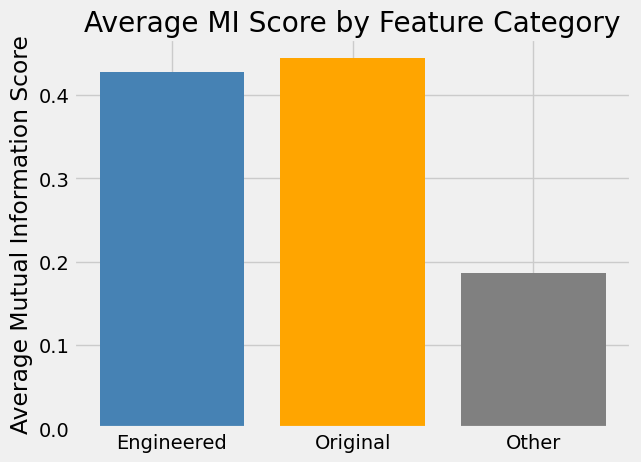

In [ ]:
# original vs engineered
original_features = [
       'month', 'week_of_year', 'weekly_season', 'weekly_market',
       'weekly_region', 'weekly_shipment_mode', 'weekly_warehouse_country',
       'weekly_avg_discount', 'weekly_avg_ship_days', 'weekly_gross_sales', 'weekly_profit'
       ]
    

engineered_features = [
    'lag_1_week_demand', 'lag_4_week_demand', 'rolling_mean_4_weeks', 'Profit Margin'
]

# Map features to category
mi_df['Category'] = mi_df['Feature'].apply(
    lambda x: 'Original' if x in original_features else 
              ('Engineered' if x in engineered_features else 'Other')
)

# Group by category and calculate average MI score
category_avg = mi_df.groupby('Category')['MI Score'].mean().reset_index()

# Print results
print(category_avg)

# Bar chart for visual comparison
import matplotlib.pyplot as plt
plt.bar(category_avg['Category'], category_avg['MI Score'], color=['steelblue', 'orange', 'grey'])
plt.ylabel('Average Mutual Information Score')
plt.title('Average MI Score by Feature Category')
plt.show()

In [1063]:
# Check for multicollinearity
X = weekly_demand_df.drop(columns=['y', 'Product Name', 'week_of_year', 'month', 'weekly_profit', 'weekly_gross_sales'])

X_vif = add_constant(X)  

vif_data = pd.DataFrame()
vif_data['Feature'] = X_vif.columns
vif_data['VIF'] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]

print(vif_data.sort_values(by='VIF', ascending=False))

                     Feature        VIF
0                      const  66.391911
10         lag_3_week_demand   2.618531
9          lag_2_week_demand   2.595327
11         lag_4_week_demand   2.263935
8          lag_1_week_demand   2.242344
6       weekly_shipment_mode   1.770414
2       weekly_avg_ship_days   1.624299
4              weekly_region   1.246016
5              weekly_season   1.231903
3              weekly_market   1.077196
7   weekly_warehouse_country   1.021811
1        weekly_avg_discount   1.012637


In [ ]:
# Prepare the final DataFrame for modeling

features = ['lag_1_week_demand', 'lag_4_week_demand', 'lag_2_week_demand', 'lag_3_week_demand',
            'weekly_avg_discount', 'weekly_avg_ship_days', 'weekly_market',
            'weekly_region', 'weekly_season', 'weekly_shipment_mode',
            'weekly_warehouse_country', 'month']

selected_skus = ['Nike Men\'s Free 5.0+ Running Shoe',
                 'O\'Brien Men\'s Neoprene Life Vest',
                 'Pelican Sunstream 100 Kayak',
                 'Perfect Fitness Perfect Rip Deck',
                 'Under Armour Women\'s Ignite Slide']

train_dfs = []
for sku in selected_skus:
    sku_df = weekly_demand_df[weekly_demand_df['Product Name'] == sku].copy()
    sku_df = sku_df.sort_index()
    
    train_df = sku_df[(sku_df.index >= '2021-01-01') & 
                      (sku_df.index <= '2022-12-31')]
    
    if len(train_df) >= 5: 
        train_dfs.append(train_df)

# tuning
tuning_df = pd.concat(train_dfs)
X_tune = tuning_df[features]
y_tune = tuning_df['y']

In [ ]:
# Hyper parameter tuning
tscv = TimeSeriesSplit(n_splits=3)

param_grid = {
    'learning_rate': [0.001, 0.01, 0.05],
    'max_depth': [3, 5, 7],
    'subsample': [0.6, 0.8, 1],
    'colsample_bytree': [0.6, 0.8, 1],
    'n_estimators': [500, 1000]
}

xgb_model = xgb.XGBRegressor(objective='reg:squarederror', 
                             tree_method='hist', 
                             random_state=42)

search = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=param_grid,
    n_iter=20,
    scoring='neg_mean_absolute_error',
    cv=tscv,
    verbose=2
)

search.fit(X_tune, y_tune)
best_params = search.best_params_
print("Best hyperparameters:", best_params)

Fitting 3 folds for each of 20 candidates, totalling 60 fits
[CV] END colsample_bytree=0.6, learning_rate=0.01, max_depth=3, n_estimators=500, subsample=0.6; total time=   0.5s
[CV] END colsample_bytree=0.6, learning_rate=0.01, max_depth=3, n_estimators=500, subsample=0.6; total time=   0.2s
[CV] END colsample_bytree=0.6, learning_rate=0.01, max_depth=3, n_estimators=500, subsample=0.6; total time=   0.2s
[CV] END colsample_bytree=0.8, learning_rate=0.05, max_depth=7, n_estimators=500, subsample=0.6; total time=   0.5s
[CV] END colsample_bytree=0.8, learning_rate=0.05, max_depth=7, n_estimators=500, subsample=0.6; total time=   0.5s
[CV] END colsample_bytree=0.8, learning_rate=0.05, max_depth=7, n_estimators=500, subsample=0.6; total time=   0.6s
[CV] END colsample_bytree=0.6, learning_rate=0.01, max_depth=5, n_estimators=500, subsample=1; total time=   0.3s
[CV] END colsample_bytree=0.6, learning_rate=0.01, max_depth=5, n_estimators=500, subsample=1; total time=   0.4s
[CV] END colsam

In [1066]:
models_metrics = {}
X_test_dict = {}
y_test_dict = {}

for sku in selected_skus:
    print(f"\n=== SKU: {sku} ===")
    
    sku_df = weekly_demand_df[weekly_demand_df['Product Name'] == sku].copy()
    # sku_df['Order Date Copy'] = pd.to_datetime(sku_df['Order Date Copy'])
    sku_df = sku_df.sort_index()
    
    # Chronological train/test split
    train_df = sku_df[(sku_df.index >= '2021-01-01') & 
                      (sku_df.index <= '2022-12-31')]
    test_df = sku_df[(sku_df.index >= '2023-01-01') & 
                     (sku_df.index <= '2023-12-31')]
    
    if len(train_df) < 5 or len(test_df) < 1:
        print("Not enough data for train/test split, skipping...")
        continue
    
    X_train, y_train = train_df[features], train_df['y']
    X_test, y_test = test_df[features], test_df['y']
    
     # Store test sets for plotting
    X_test_dict[sku] = X_test
    y_test_dict[sku] = y_test
    
    # Train model
    model = xgb.XGBRegressor(**best_params)
    model.fit(X_train, y_train)
    
    def smape(y_true, y_pred):
        return 100 * np.mean(
        np.abs(y_pred - y_true) / ((np.abs(y_true) + np.abs(y_pred)) / 2 + 1e-8)
    )
    
    # Predict & evaluate
    y_pred = model.predict(X_test)
    mae = mean_absolute_error(y_test, y_pred)
    mape = (np.abs((y_test - y_pred) / y_test.replace(0, 1))).mean()
    smape_val = smape(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    
    mean_demand = y_train.mean()
    std_demand = y_train.std()
    print(f"Training Set Context -> Mean Demand: {round(mean_demand,2)}, Std Dev: {round(std_demand,2)}")
    
    print(f"MAE: {round(mae,2)}, MAPE: {round(mape*100,2)}%, RMSE: {round(rmse,2)}, R2: {round(r2,2)}, SMAPE: {round(smape_val,2)}%")
    
    models_metrics[sku] = {'model': model, 'MAE': mae, 'MAPE': mape, 'RMSE': rmse, 'R2': r2, 'SMAPE': smape_val}


=== SKU: Nike Men's Free 5.0+ Running Shoe ===
Training Set Context -> Mean Demand: 44.78, Std Dev: 26.3
MAE: 20.83, MAPE: 614.36%, RMSE: 28.25, R2: 0.29, SMAPE: 64.53%

=== SKU: O'Brien Men's Neoprene Life Vest ===
Training Set Context -> Mean Demand: 71.2, Std Dev: 37.78
MAE: 24.08, MAPE: 50.76%, RMSE: 30.55, R2: 0.45, SMAPE: 40.15%

=== SKU: Pelican Sunstream 100 Kayak ===
Training Set Context -> Mean Demand: 18.74, Std Dev: 11.43
MAE: 4.8, MAPE: 61.21%, RMSE: 5.96, R2: 0.8, SMAPE: 39.48%

=== SKU: Perfect Fitness Perfect Rip Deck ===
Training Set Context -> Mean Demand: 90.61, Std Dev: 51.24
MAE: 31.88, MAPE: 1075.35%, RMSE: 43.54, R2: 0.5, SMAPE: 63.81%

=== SKU: Under Armour Women's Ignite Slide ===
Training Set Context -> Mean Demand: 3.87, Std Dev: 2.58
MAE: 1.48, MAPE: 128.21%, RMSE: 1.84, R2: -1.71, SMAPE: 62.08%


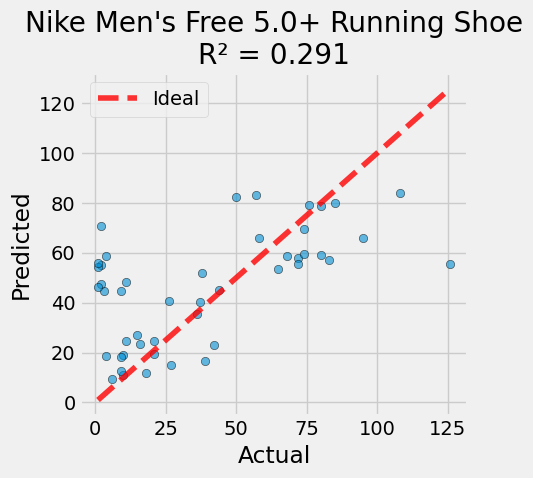

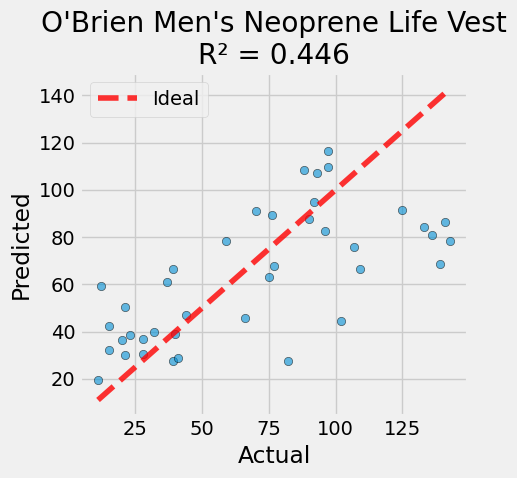

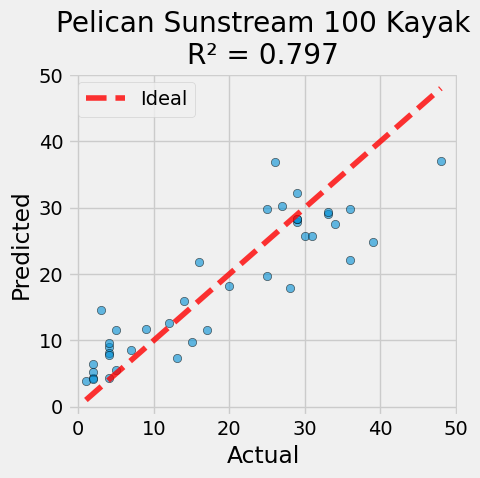

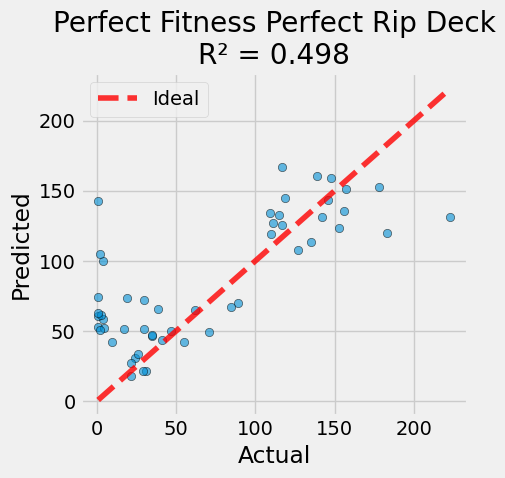

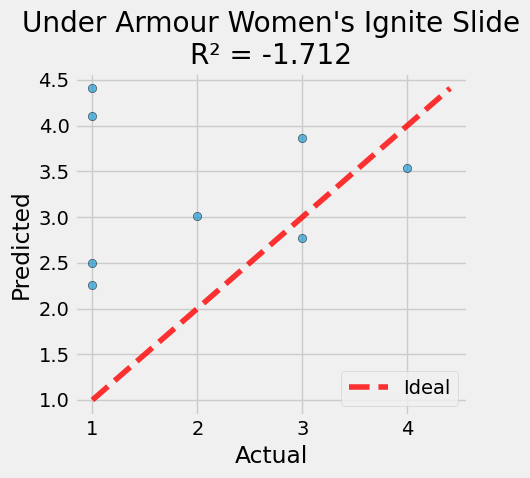

In [ ]:
def plot_predicted_vs_actual(models_metrics, X_test_dict, y_test_dict):
    for sku, data in models_metrics.items():
        model = data['model']
        X_test = X_test_dict[sku]
        y_test = y_test_dict[sku]
        
        # Predictions
        y_pred = model.predict(X_test)
        
        # R2 score
        r2 = r2_score(y_test, y_pred)
        
        # Scatter plot
        plt.figure(figsize=(5,5))
        plt.scatter(y_test, y_pred, alpha=0.6, edgecolors="k")
        
        lims = [
            np.min([y_test.min(), y_pred.min()]),
            np.max([y_test.max(), y_pred.max()])
        ]
        plt.plot(lims, lims, "r--", alpha=0.8, label="Ideal")
        
        plt.xlabel("Actual")
        plt.ylabel("Predicted")
        plt.title(f"{sku}\nR² = {r2:.3f}")
        plt.legend()
        plt.tight_layout()
        plt.show()
        
plot_predicted_vs_actual(models_metrics, X_test_dict, y_test_dict)

In [1068]:
# create a log-transformed target variable
weekly_demand_df['y_log'] = np.log1p(weekly_demand_df['y'])

In [ ]:
# final DataFrame for modeling

features = ['lag_1_week_demand', 'lag_4_week_demand', 'lag_2_week_demand', 'lag_3_week_demand',
            'weekly_avg_discount', 'weekly_avg_ship_days', 'weekly_market',
            'weekly_region', 'weekly_season', 'weekly_shipment_mode',
            'weekly_warehouse_country', 'month']

selected_skus = ['Nike Men\'s Free 5.0+ Running Shoe',
                 'O\'Brien Men\'s Neoprene Life Vest',
                 'Pelican Sunstream 100 Kayak',
                 'Perfect Fitness Perfect Rip Deck',
                 'Under Armour Women\'s Ignite Slide']

train_dfs = []
for sku in selected_skus:
    sku_df = weekly_demand_df[weekly_demand_df['Product Name'] == sku].copy()
    sku_df = sku_df.sort_index()
    
    train_df = sku_df[(sku_df.index >= '2021-01-01') & 
                      (sku_df.index <= '2022-12-31')]
    
    if len(train_df) >= 5: 
        train_dfs.append(train_df)

# Combine all SKUs for tuning
tuning_df = pd.concat(train_dfs)
X_tune = tuning_df[features]
y_tune = tuning_df['y_log']

In [1070]:
# Hyper parameter tuning

tscv = TimeSeriesSplit(n_splits=3)

param_grid = {
    'learning_rate': [0.001, 0.01, 0.05],
    'max_depth': [3, 5, 7],
    'subsample': [0.6, 0.8, 1],
    'colsample_bytree': [0.6, 0.8, 1],
    'n_estimators': [500, 1000]
}

xgb_model = xgb.XGBRegressor(objective='reg:squarederror', 
                             tree_method='hist', 
                             random_state=42)

search = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=param_grid,
    n_iter=20,
    scoring='neg_mean_absolute_error',
    cv=tscv,
    verbose=2
)

search.fit(X_tune, y_tune)
best_params = search.best_params_
print("Best hyperparameters:", best_params)

Fitting 3 folds for each of 20 candidates, totalling 60 fits
[CV] END colsample_bytree=0.6, learning_rate=0.01, max_depth=5, n_estimators=500, subsample=0.8; total time=   0.6s
[CV] END colsample_bytree=0.6, learning_rate=0.01, max_depth=5, n_estimators=500, subsample=0.8; total time=   0.4s
[CV] END colsample_bytree=0.6, learning_rate=0.01, max_depth=5, n_estimators=500, subsample=0.8; total time=   0.4s
[CV] END colsample_bytree=1, learning_rate=0.001, max_depth=5, n_estimators=500, subsample=1; total time=   1.2s
[CV] END colsample_bytree=1, learning_rate=0.001, max_depth=5, n_estimators=500, subsample=1; total time=   0.6s
[CV] END colsample_bytree=1, learning_rate=0.001, max_depth=5, n_estimators=500, subsample=1; total time=   0.4s
[CV] END colsample_bytree=0.8, learning_rate=0.05, max_depth=5, n_estimators=500, subsample=0.6; total time=   0.6s
[CV] END colsample_bytree=0.8, learning_rate=0.05, max_depth=5, n_estimators=500, subsample=0.6; total time=   1.7s
[CV] END colsample_b

In [ ]:
models_metrics = {}
X_test_dict = {}
y_test_dict = {}

for sku in selected_skus:
    print(f"\n=== SKU: {sku} ===")
    
    sku_df = weekly_demand_df[weekly_demand_df['Product Name'] == sku].copy()
    # sku_df['Order Date Copy'] = pd.to_datetime(sku_df['Order Date Copy'])
    sku_df = sku_df.sort_index()
    
    # Chronological train/test split
    train_df = sku_df[(sku_df.index >= '2021-01-01') & 
                      (sku_df.index <= '2022-12-31')]
    test_df = sku_df[(sku_df.index >= '2023-01-01') & 
                     (sku_df.index <= '2023-12-31')]
    
    if len(train_df) < 5 or len(test_df) < 1:
        print("Not enough data for train/test split, skipping...")
        continue
    
    X_train, y_train = train_df[features], train_df['y_log']
    X_test, y_test = test_df[features], test_df['y_log']
    
     # Test sets for plotting
    X_test_dict[sku] = X_test
    y_test_dict[sku] = y_test
    
    # Train model
    model = xgb.XGBRegressor(**best_params)
    model.fit(X_train, y_train)
    
    def smape(y_true, y_pred):
        return 100 * np.mean(
        np.abs(y_pred - y_true) / ((np.abs(y_true) + np.abs(y_pred)) / 2 + 1e-8)
    )
    
    # Predict & evaluate
    y_pred_log = model.predict(X_test)
    y_pred = np.expm1(y_pred_log)
    mae = mean_absolute_error(y_test, y_pred)
    mape = (np.abs((y_test - y_pred) / y_test.replace(0, 1))).mean()
    smape_val = smape(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    
    mean_demand = y_train.mean()
    std_demand = y_train.std()
    print(f"Training Set Context -> Mean Demand: {round(mean_demand,2)}, Std Dev: {round(std_demand,2)}")
    
    print(f"MAE: {round(mae,2)}, MAPE: {round(mape*100,2)}%, RMSE: {round(rmse,2)}, R2: {round(r2,2)}, SMAPE: {round(smape_val,2)}%")
    
    models_metrics[sku] = {'model': model, 'MAE': mae, 'MAPE': mape, 'RMSE': rmse, 'R2': r2, 'SMAPE': smape_val}


=== SKU: Nike Men's Free 5.0+ Running Shoe ===
Training Set Context -> Mean Demand: 3.61, Std Dev: 0.72
MAE: 37.54, MAPE: 1532.54%, RMSE: 42.61, R2: -1196.24, SMAPE: 164.76%

=== SKU: O'Brien Men's Neoprene Life Vest ===
Training Set Context -> Mean Demand: 4.12, Std Dev: 0.61
MAE: 54.25, MAPE: 1307.79%, RMSE: 60.16, R2: -6779.59, SMAPE: 170.2%

=== SKU: Pelican Sunstream 100 Kayak ===
Training Set Context -> Mean Demand: 2.74, Std Dev: 0.79
MAE: 14.44, MAPE: 497.23%, RMSE: 17.41, R2: -344.63, SMAPE: 135.77%

=== SKU: Perfect Fitness Perfect Rip Deck ===
Training Set Context -> Mean Demand: 4.31, Std Dev: 0.71
MAE: 74.36, MAPE: 2569.98%, RMSE: 87.01, R2: -3473.71, SMAPE: 178.03%

=== SKU: Under Armour Women's Ignite Slide ===
Training Set Context -> Mean Demand: 1.45, Std Dev: 0.52
MAE: 2.03, MAPE: 237.71%, RMSE: 2.25, R2: -37.61, SMAPE: 97.08%


In [ ]:
# Check how many are negative
num_negative = (y_pred_log < 0).sum()
print(f"Number of negative log predictions: {num_negative}")

Number of negative log predictions: 0


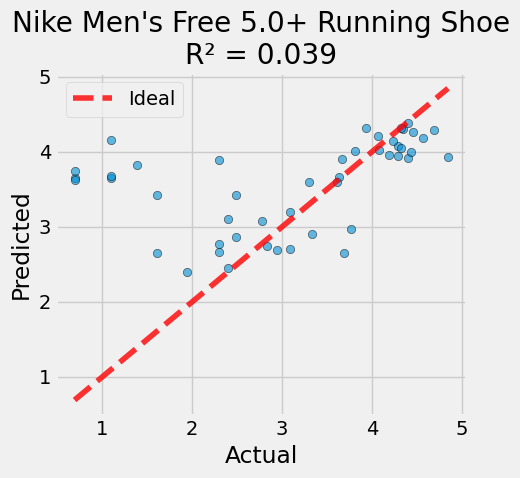

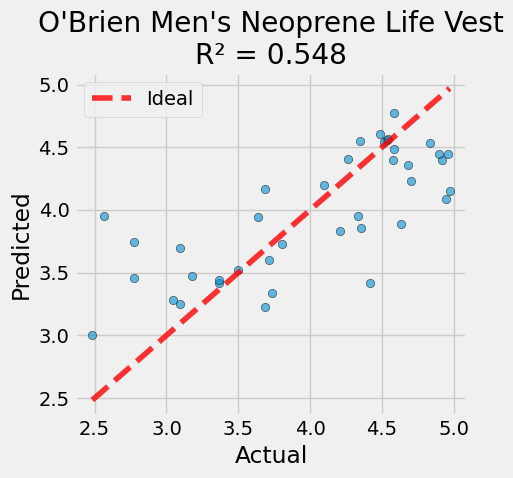

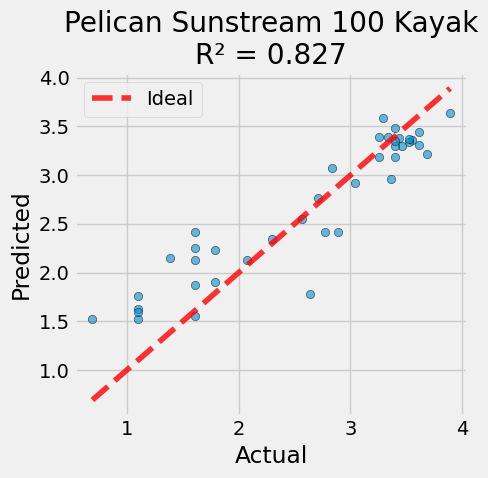

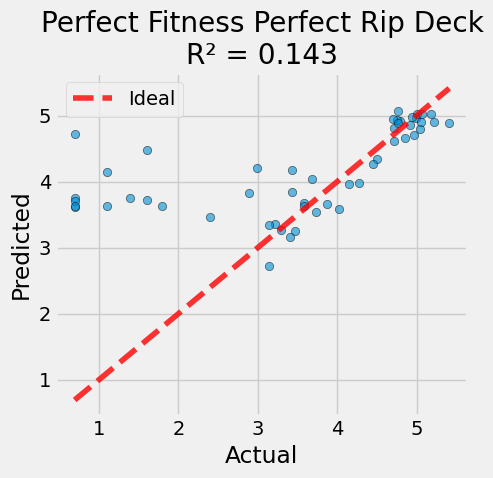

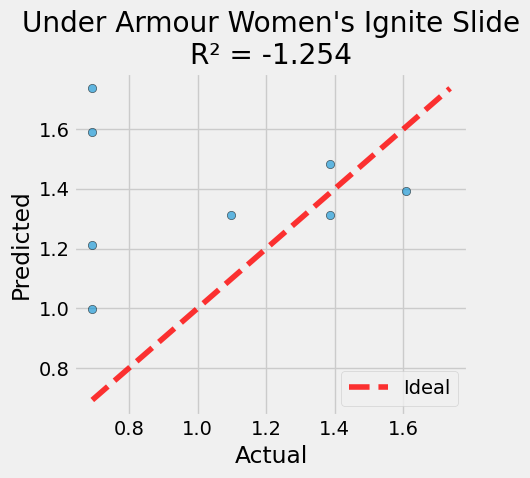

In [ ]:
def plot_predicted_vs_actual(models_metrics, X_test_dict, y_test_dict):
    for sku, data in models_metrics.items():
        model = data['model']
        X_test = X_test_dict[sku]
        y_test = y_test_dict[sku]
        
        # Predictions
        y_pred = model.predict(X_test)
        
        # R² score
        r2 = r2_score(y_test, y_pred)
        
        # Scatter plot
        plt.figure(figsize=(5,5))
        plt.scatter(y_test, y_pred, alpha=0.6, edgecolors="k")
        
        lims = [
            np.min([y_test.min(), y_pred.min()]),
            np.max([y_test.max(), y_pred.max()])
        ]
        plt.plot(lims, lims, "r--", alpha=0.8, label="Ideal")
        
        plt.xlabel("Actual")
        plt.ylabel("Predicted")
        plt.title(f"{sku}\nR² = {r2:.3f}")
        plt.legend()
        plt.tight_layout()
        plt.show()
        
plot_predicted_vs_actual(models_metrics, X_test_dict, y_test_dict)

### <center>**Montly basis XGBoost Model**

In [ ]:

monthly_demand_df = df_filtered.groupby(
    ['Product Name', pd.Grouper(level='Order Date', freq='M')]
).agg(
    y=('Order Quantity', 'sum'),                  
    monthly_gross_sales=('Gross Sales', 'sum'),    
    monthly_profit=('Profit', 'sum'),              
    monthly_avg_discount=('Discount %', 'mean'), 
    monthly_avg_ship_days=('Shipment Days - Scheduled', 'mean'),
    monthly_market=('Customer Market Encoded', lambda x: x.mode()[0]),  
    monthly_region=('Customer Region Encoded', lambda x: x.mode()[0]),
    monthly_season=('Season Encoded', lambda x: x.mode()[0]),
    monthly_shipment_mode=('Shipment Mode Encoded', lambda x: x.mode()[0]),
    monthly_warehouse_country=('Warehouse Country Encoded', lambda x: x.mode()[0])
).reset_index()
monthly_demand_df.set_index('Order Date', inplace=True)
monthly_demand_df.rename(columns={'Order Quantity': 'y'}, inplace=True)

# Create Lag and Rolling Window Features 
monthly_demand_df['lag_1_month_demand'] = monthly_demand_df.groupby('Product Name')['y'].shift(1)
monthly_demand_df['lag_2_month_demand'] = monthly_demand_df.groupby('Product Name')['y'].shift(2)
monthly_demand_df['lag_3_month_demand'] = monthly_demand_df.groupby('Product Name')['y'].shift(3)
monthly_demand_df['lag_4_month_demand'] = monthly_demand_df.groupby('Product Name')['y'].shift(4)

# Fix the null values created by shifting
monthly_demand_df.fillna(0, inplace=True)

# Add other known features
monthly_demand_df['month'] = monthly_demand_df.index.month

/var/folders/x2/xzn0478s38vfcsjrc5rzqfyr0000gn/T/ipykernel_68648/3813939839.py:9: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  ['Product Name', pd.Grouper(level='Order Date', freq='M')]


                      Feature  MI Score
0         monthly_gross_sales  2.368656
1              monthly_profit  2.021470
9          lag_1_month_demand  0.986769
10         lag_2_month_demand  0.980615
11         lag_3_month_demand  0.877650
12         lag_4_month_demand  0.761816
3       monthly_avg_ship_days  0.283168
2        monthly_avg_discount  0.246194
7       monthly_shipment_mode  0.152588
8   monthly_warehouse_country  0.032744
5              monthly_region  0.000000
4              monthly_market  0.000000
6              monthly_season  0.000000
13                      month  0.000000


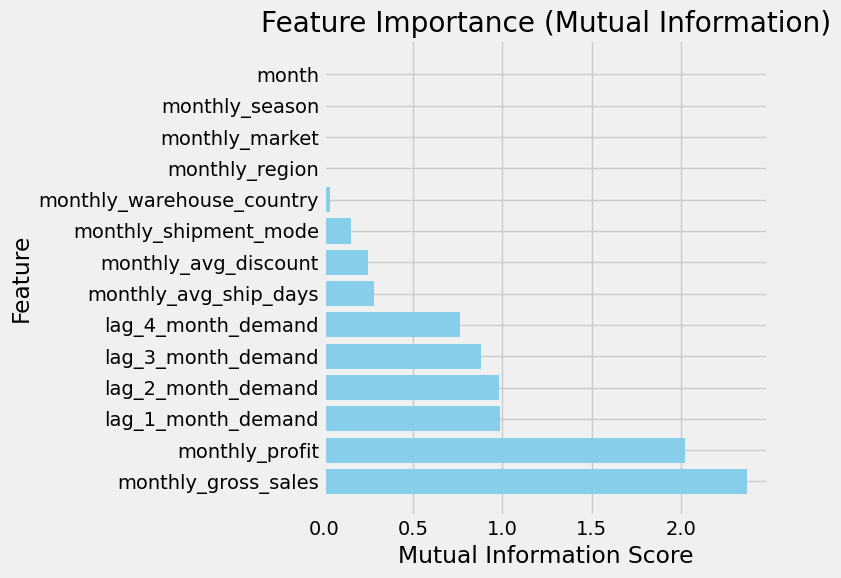

In [ ]:
# Separate features and target
X_mutual = monthly_demand_df.drop(columns=['y', 'Product Name'])  
y_mutual = monthly_demand_df['y']

# Calculate mutual information scores
mi_scores = mutual_info_regression(X_mutual, y_mutual, discrete_features='auto', random_state=42)

# DataFrame for easier viewing
mi_df = pd.DataFrame({
    'Feature': X_mutual.columns,
    'MI Score': mi_scores
}).sort_values(by='MI Score', ascending=False)

print(mi_df)

# Plot
plt.figure(figsize=(8, 6))
plt.barh(mi_df['Feature'], mi_df['MI Score'], color='skyblue')
plt.xlabel("Mutual Information Score")
plt.ylabel("Feature")
plt.title("Feature Importance (Mutual Information)")
plt.tight_layout()
plt.show()

In [1076]:
# Check for multicollinearity
X = monthly_demand_df.drop(columns=['y', 'Product Name', 'month', 'monthly_profit', 'monthly_gross_sales'])

X_vif = add_constant(X)  

vif_data = pd.DataFrame()
vif_data['Feature'] = X_vif.columns
vif_data['VIF'] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]

print(vif_data.sort_values(by='VIF', ascending=False))

                      Feature         VIF
0                       const  104.072420
10         lag_3_month_demand    6.516675
9          lag_2_month_demand    6.020205
11         lag_4_month_demand    5.724560
8          lag_1_month_demand    4.334574
6       monthly_shipment_mode    1.833763
2       monthly_avg_ship_days    1.549494
4              monthly_region    1.540355
5              monthly_season    1.512422
7   monthly_warehouse_country    1.223392
3              monthly_market    1.194481
1        monthly_avg_discount    1.112745


In [ ]:
# Final DataFrame for modeling

features = ['lag_1_month_demand', 'lag_4_month_demand', 'lag_2_month_demand', 'lag_3_month_demand',
            'monthly_avg_discount', 'monthly_avg_ship_days', 'monthly_market',
            'monthly_region', 'monthly_season', 'monthly_shipment_mode',
            'monthly_warehouse_country', 'month']

selected_skus = ['Nike Men\'s Free 5.0+ Running Shoe',
                 'O\'Brien Men\'s Neoprene Life Vest',
                 'Pelican Sunstream 100 Kayak',
                 'Perfect Fitness Perfect Rip Deck',
                 'Under Armour Women\'s Ignite Slide']

train_dfs = []
for sku in selected_skus:
    sku_df = monthly_demand_df[monthly_demand_df['Product Name'] == sku].copy()
    sku_df = sku_df.sort_index()
    
    train_df = sku_df[(sku_df.index >= '2021-01-01') & 
                      (sku_df.index <= '2022-12-31')]
    
    if len(train_df) >= 5: 
        train_dfs.append(train_df)

# Combine all products for tuning
tuning_df = pd.concat(train_dfs)
X_tune = tuning_df[features]
y_tune = tuning_df['y']

In [1078]:
# Hyper parameter tuning

tscv = TimeSeriesSplit(n_splits=3)

param_grid = {
    'learning_rate': [0.001, 0.01, 0.05],
    'max_depth': [3, 5, 7],
    'subsample': [0.6, 0.8, 1],
    'colsample_bytree': [0.6, 0.8, 1],
    'n_estimators': [500, 1000]
}

xgb_model = xgb.XGBRegressor(objective='reg:squarederror', 
                             tree_method='hist', 
                             random_state=42)

search = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=param_grid,
    n_iter=20,
    scoring='neg_mean_absolute_error',
    cv=tscv,
    verbose=2
)

search.fit(X_tune, y_tune)
best_params = search.best_params_
print("Best hyperparameters:", best_params)

Fitting 3 folds for each of 20 candidates, totalling 60 fits
[CV] END colsample_bytree=1, learning_rate=0.01, max_depth=7, n_estimators=500, subsample=0.6; total time=   0.6s
[CV] END colsample_bytree=1, learning_rate=0.01, max_depth=7, n_estimators=500, subsample=0.6; total time=   0.4s
[CV] END colsample_bytree=1, learning_rate=0.01, max_depth=7, n_estimators=500, subsample=0.6; total time=   0.4s
[CV] END colsample_bytree=1, learning_rate=0.01, max_depth=5, n_estimators=1000, subsample=0.6; total time=   0.5s
[CV] END colsample_bytree=1, learning_rate=0.01, max_depth=5, n_estimators=1000, subsample=0.6; total time=   0.6s
[CV] END colsample_bytree=1, learning_rate=0.01, max_depth=5, n_estimators=1000, subsample=0.6; total time=   0.6s
[CV] END colsample_bytree=0.6, learning_rate=0.001, max_depth=7, n_estimators=1000, subsample=0.6; total time=   0.6s
[CV] END colsample_bytree=0.6, learning_rate=0.001, max_depth=7, n_estimators=1000, subsample=0.6; total time=   0.6s
[CV] END colsamp

In [1079]:
models_metrics = {}
X_test_dict = {}
y_test_dict = {}

for sku in selected_skus:
    print(f"\n=== SKU: {sku} ===")
    
    sku_df = monthly_demand_df[monthly_demand_df['Product Name'] == sku].copy()
    # sku_df['Order Date Copy'] = pd.to_datetime(sku_df['Order Date Copy'])
    sku_df = sku_df.sort_index()
    
    # Chronological train/test split
    train_df = sku_df[(sku_df.index >= '2021-01-01') & 
                      (sku_df.index <= '2022-12-31')]
    test_df = sku_df[(sku_df.index >= '2023-01-01') & 
                     (sku_df.index <= '2023-12-31')]
    
    if len(train_df) < 5 or len(test_df) < 1:
        print("Not enough data for train/test split, skipping...")
        continue
    
    X_train, y_train = train_df[features], train_df['y']
    X_test, y_test = test_df[features], test_df['y']
    
     # Store test sets for plotting
    X_test_dict[sku] = X_test
    y_test_dict[sku] = y_test
    
    # Train model
    model = xgb.XGBRegressor(**best_params)
    model.fit(X_train, y_train)
    
    def smape(y_true, y_pred):
        return 100 * np.mean(
        np.abs(y_pred - y_true) / ((np.abs(y_true) + np.abs(y_pred)) / 2 + 1e-8)
    )
    
    # Predict & evaluate
    y_pred = model.predict(X_test)
    mae = mean_absolute_error(y_test, y_pred)
    mape = (np.abs((y_test - y_pred) / y_test.replace(0, 1))).mean()
    smape_val = smape(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    
    mean_demand = y_train.mean()
    std_demand = y_train.std()
    print(f"Training Set Context -> Mean Demand: {round(mean_demand,2)}, Std Dev: {round(std_demand,2)}")
    
    print(f"MAE: {round(mae,2)}, MAPE: {round(mape*100,2)}%, RMSE: {round(rmse,2)}, R2: {round(r2,2)}, SMAPE: {round(smape_val,2)}%")
    
    models_metrics[sku] = {'model': model, 'MAE': mae, 'MAPE': mape, 'RMSE': rmse, 'R2': r2, 'SMAPE': smape_val}


=== SKU: Nike Men's Free 5.0+ Running Shoe ===
Training Set Context -> Mean Demand: 195.5, Std Dev: 33.08
MAE: 67.25, MAPE: 1090.02%, RMSE: 95.51, R2: -0.25, SMAPE: 58.56%

=== SKU: O'Brien Men's Neoprene Life Vest ===
Training Set Context -> Mean Demand: 312.46, Std Dev: 51.92
MAE: 69.77, MAPE: 658.36%, RMSE: 113.42, R2: -0.48, SMAPE: 32.27%

=== SKU: Pelican Sunstream 100 Kayak ===
Training Set Context -> Mean Demand: 82.21, Std Dev: 11.67
MAE: 12.22, MAPE: 16.77%, RMSE: 15.14, R2: -0.99, SMAPE: 15.05%

=== SKU: Perfect Fitness Perfect Rip Deck ===
Training Set Context -> Mean Demand: 397.08, Std Dev: 48.79
MAE: 133.65, MAPE: 1091.33%, RMSE: 206.6, R2: -0.62, SMAPE: 56.34%

=== SKU: Under Armour Women's Ignite Slide ===
Training Set Context -> Mean Demand: 8.11, Std Dev: 4.91
MAE: 4.14, MAPE: 325.55%, RMSE: 6.11, R2: -19.29, SMAPE: 79.17%


In [1080]:
# create a log-transformed target variable
monthly_demand_df['y_log'] = np.log1p(monthly_demand_df['y'])

In [ ]:
# Final DataFrame for modeling

train_dfs = []
for sku in selected_skus:
    sku_df = monthly_demand_df[monthly_demand_df['Product Name'] == sku].copy()
    sku_df = sku_df.sort_index()
    
    train_df = sku_df[(sku_df.index >= '2021-01-01') & 
                      (sku_df.index <= '2022-12-31')]
    
    if len(train_df) >= 5: 
        train_dfs.append(train_df)

# Combine all SKUs for tuning
tuning_df = pd.concat(train_dfs)
X_tune = tuning_df[features]
y_tune = tuning_df['y_log']

In [1082]:
# Hyper parameter tuning

tscv = TimeSeriesSplit(n_splits=3)

param_grid = {
    'learning_rate': [0.001, 0.01, 0.05],
    'max_depth': [3, 5, 7],
    'subsample': [0.6, 0.8, 1],
    'colsample_bytree': [0.6, 0.8, 1],
    'n_estimators': [500, 1000]
}

xgb_model = xgb.XGBRegressor(objective='reg:squarederror', 
                             tree_method='hist', 
                             random_state=42)

search = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=param_grid,
    n_iter=20,
    scoring='neg_mean_absolute_error',
    cv=tscv,
    verbose=2
)

search.fit(X_tune, y_tune)
best_params = search.best_params_
print("Best hyperparameters:", best_params)

Fitting 3 folds for each of 20 candidates, totalling 60 fits
[CV] END colsample_bytree=0.8, learning_rate=0.01, max_depth=3, n_estimators=1000, subsample=1; total time=   0.7s
[CV] END colsample_bytree=0.8, learning_rate=0.01, max_depth=3, n_estimators=1000, subsample=1; total time=   0.4s
[CV] END colsample_bytree=0.8, learning_rate=0.01, max_depth=3, n_estimators=1000, subsample=1; total time=   0.4s
[CV] END colsample_bytree=1, learning_rate=0.05, max_depth=3, n_estimators=1000, subsample=1; total time=   0.3s
[CV] END colsample_bytree=1, learning_rate=0.05, max_depth=3, n_estimators=1000, subsample=1; total time=   0.4s
[CV] END colsample_bytree=1, learning_rate=0.05, max_depth=3, n_estimators=1000, subsample=1; total time=   0.4s
[CV] END colsample_bytree=0.6, learning_rate=0.05, max_depth=5, n_estimators=1000, subsample=0.6; total time=   0.4s
[CV] END colsample_bytree=0.6, learning_rate=0.05, max_depth=5, n_estimators=1000, subsample=0.6; total time=   0.5s
[CV] END colsample_by

In [ ]:
models_metrics = {}
X_test_dict = {}
y_test_dict = {}

for sku in selected_skus:
    print(f"\n=== SKU: {sku} ===")
    
    sku_df = monthly_demand_df[monthly_demand_df['Product Name'] == sku].copy()
    # sku_df['Order Date Copy'] = pd.to_datetime(sku_df['Order Date Copy'])
    sku_df = sku_df.sort_index()
    
    # Chronological train/test split
    train_df = sku_df[(sku_df.index >= '2021-01-01') & 
                      (sku_df.index <= '2022-12-31')]
    test_df = sku_df[(sku_df.index >= '2023-01-01') & 
                     (sku_df.index <= '2023-12-31')]
    
    if len(train_df) < 5 or len(test_df) < 1:
        print("Not enough data for train/test split, skipping...")
        continue
    
    X_train, y_train = train_df[features], train_df['y_log']
    X_test, y_test = test_df[features], test_df['y_log']
    
     # Test sets for plotting
    X_test_dict[sku] = X_test
    y_test_dict[sku] = y_test
    
    # Train model
    model = xgb.XGBRegressor(**best_params)
    model.fit(X_train, y_train)
    
    def smape(y_true, y_pred):
        return 100 * np.mean(
        np.abs(y_pred - y_true) / ((np.abs(y_true) + np.abs(y_pred)) / 2 + 1e-8)
    )
    
    # Predict & evaluate
    y_pred_log = model.predict(X_test)
    y_pred = np.expm1(y_pred_log)
    y_test_orig = np.expm1(y_test)
    mae = mean_absolute_error(y_test_orig, y_pred)
    mape = (np.abs((y_test_orig - y_pred) / y_test_orig.replace(0, 1))).mean()
    smape_val = smape(y_test_orig, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test_orig, y_pred))
    r2 = r2_score(y_test_orig, y_pred)
    
    print(f"MAE: {round(mae,2)}, MAPE: {round(mape*100,2)}%, RMSE: {round(rmse,2)}, R2: {round(r2,2)}, SMAPE: {round(smape_val,2)}%")
    
    models_metrics[sku] = {'model': model, 'MAE': mae, 'MAPE': mape, 'RMSE': rmse, 'R2': r2, 'SMAPE': smape_val}


=== SKU: Nike Men's Free 5.0+ Running Shoe ===
MAE: 65.23, MAPE: 1123.25%, RMSE: 97.04, R2: -0.29, SMAPE: 57.54%

=== SKU: O'Brien Men's Neoprene Life Vest ===
MAE: 68.93, MAPE: 626.82%, RMSE: 108.94, R2: -0.37, SMAPE: 32.55%

=== SKU: Pelican Sunstream 100 Kayak ===
MAE: 10.0, MAPE: 13.95%, RMSE: 12.59, R2: -0.38, SMAPE: 12.65%

=== SKU: Perfect Fitness Perfect Rip Deck ===
MAE: 122.37, MAPE: 1010.72%, RMSE: 192.54, R2: -0.41, SMAPE: 55.15%

=== SKU: Under Armour Women's Ignite Slide ===
MAE: 2.32, MAPE: 177.55%, RMSE: 3.14, R2: -4.37, SMAPE: 65.12%


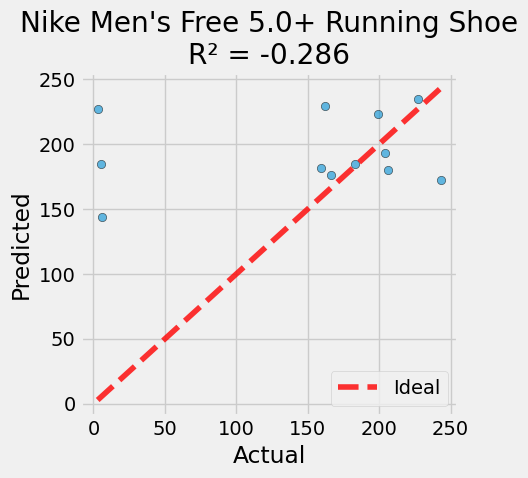

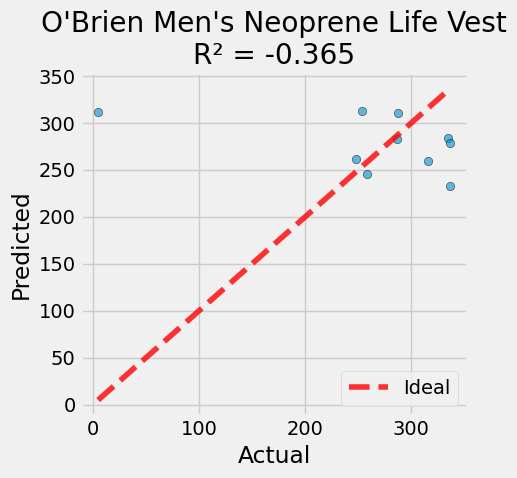

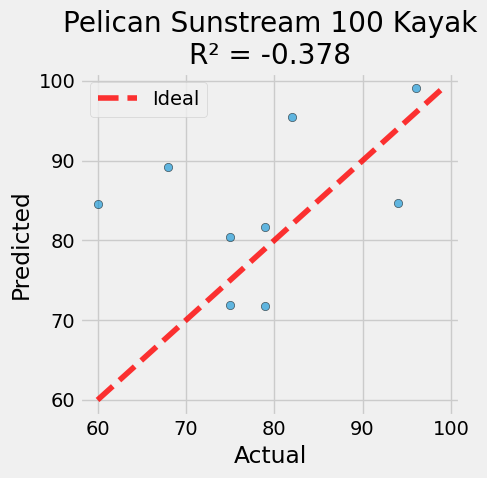

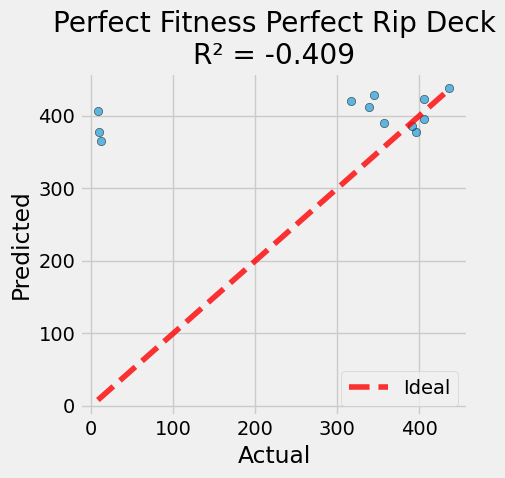

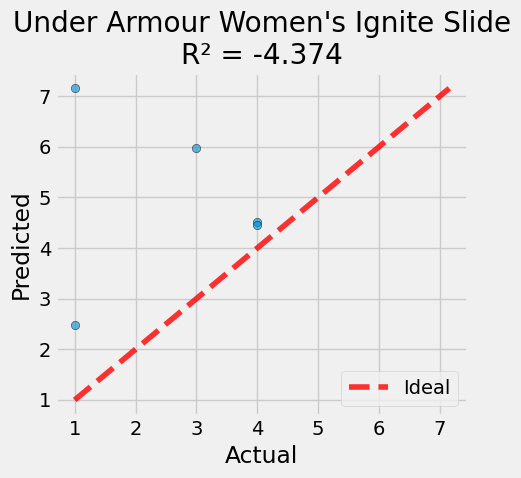

In [ ]:
def plot_predicted_vs_actual(models_metrics, X_test_dict, y_test_dict):
    for sku, data in models_metrics.items():
        model = data['model']
        X_test = X_test_dict[sku]
        y_test = y_test_dict[sku]
        
        # Predictions
        y_pred_log = model.predict(X_test)
        y_pred = np.expm1(y_pred_log)
        y_test = np.expm1(y_test)
        
        # R² score
        r2 = r2_score(y_test, y_pred)
        
        # Scatter plot
        plt.figure(figsize=(5,5))
        plt.scatter(y_test, y_pred, alpha=0.6, edgecolors="k")
        
        lims = [
            np.min([y_test.min(), y_pred.min()]),
            np.max([y_test.max(), y_pred.max()])
        ]
        plt.plot(lims, lims, "r--", alpha=0.8, label="Ideal")
        
        plt.xlabel("Actual")
        plt.ylabel("Predicted")
        plt.title(f"{sku}\nR² = {r2:.3f}")
        plt.legend()
        plt.tight_layout()
        plt.show()
        
plot_predicted_vs_actual(models_metrics, X_test_dict, y_test_dict)

## <center>**RandomForest Regressor**

                     Feature  MI Score
15                     y_log  4.304903
0         weekly_gross_sales  2.620420
1              weekly_profit  1.705029
12         lag_4_week_demand  0.640055
3       weekly_avg_ship_days  0.307562
10         lag_2_week_demand  0.233419
9          lag_1_week_demand  0.207281
2        weekly_avg_discount  0.126405
11         lag_3_week_demand  0.123656
7       weekly_shipment_mode  0.118277
8   weekly_warehouse_country  0.029587
5              weekly_region  0.021685
4              weekly_market  0.018490
6              weekly_season  0.000000
13                     month  0.000000
14              week_of_year  0.000000


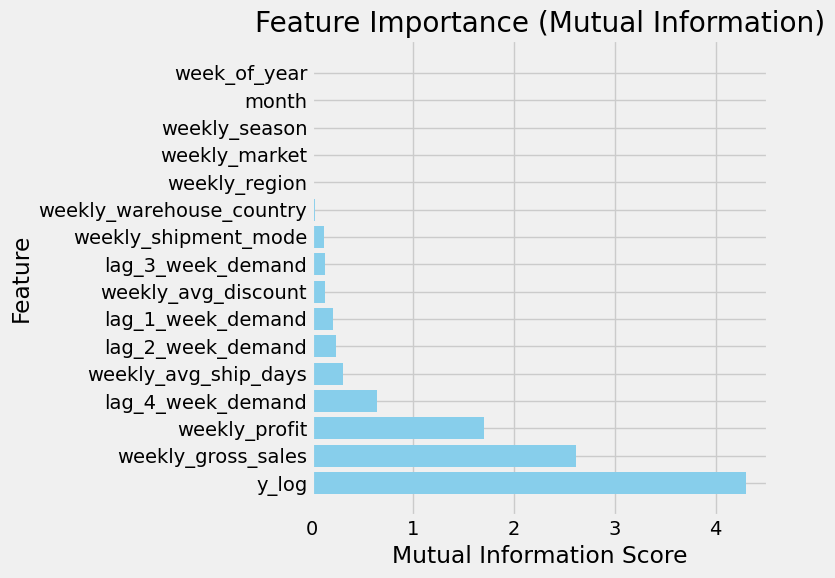

In [ ]:
# Separate features and target
X_mutual = weekly_demand_df.drop(columns=['y', 'Product Name'])  
y_mutual = weekly_demand_df['y']

# Calculate mutual information scores
mi_scores = mutual_info_regression(X_mutual, y_mutual, discrete_features='auto', random_state=42)

# DataFrame for easier viewing
mi_df = pd.DataFrame({
    'Feature': X_mutual.columns,
    'MI Score': mi_scores
}).sort_values(by='MI Score', ascending=False)

print(mi_df)

# Plot
plt.figure(figsize=(8, 6))
plt.barh(mi_df['Feature'], mi_df['MI Score'], color='skyblue')
plt.xlabel("Mutual Information Score")
plt.ylabel("Feature")
plt.title("Feature Importance (Mutual Information)")
plt.tight_layout()
plt.show()

In [1103]:
# Check for multicollinearity
X = weekly_demand_df.drop(columns=['y', 'Product Name', 'week_of_year', 'month', 'weekly_profit', 'weekly_gross_sales', 'y_log'])

X_vif = add_constant(X)  

vif_data = pd.DataFrame()
vif_data['Feature'] = X_vif.columns
vif_data['VIF'] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]

print(vif_data.sort_values(by='VIF', ascending=False))

                     Feature        VIF
0                      const  66.391911
10         lag_3_week_demand   2.618531
9          lag_2_week_demand   2.595327
11         lag_4_week_demand   2.263935
8          lag_1_week_demand   2.242344
6       weekly_shipment_mode   1.770414
2       weekly_avg_ship_days   1.624299
4              weekly_region   1.246016
5              weekly_season   1.231903
3              weekly_market   1.077196
7   weekly_warehouse_country   1.021811
1        weekly_avg_discount   1.012637


In [ ]:
feature = ['lag_1_week_demand', 'lag_4_week_demand', 'lag_2_week_demand', 'lag_3_week_demand',
            'weekly_avg_discount', 'weekly_avg_ship_days', 'weekly_market',
            'weekly_region', 'weekly_season', 'weekly_shipment_mode',
            'weekly_warehouse_country', 'month']

selected_skus = ['Nike Men\'s Free 5.0+ Running Shoe',
                 'O\'Brien Men\'s Neoprene Life Vest',
                 'Pelican Sunstream 100 Kayak',
                 'Perfect Fitness Perfect Rip Deck',
                 'Under Armour Women\'s Ignite Slide']

train_dfs = []

for sku in selected_skus:
    sku_df = weekly_demand_df[weekly_demand_df['Product Name'] == sku].copy()
    sku_df = sku_df.sort_index()
    
    train_df = sku_df[(sku_df.index >= '2021-01-01') & 
                      (sku_df.index <= '2022-12-31')]
    
    if len(train_df) >= 5:  
        train_dfs.append(train_df)

tuning_df = pd.concat(train_dfs)
X_tune = tuning_df[feature]
y_tune = tuning_df['y']

In [1106]:
# Hyperparameter tuning for Random Forest
tscv = TimeSeriesSplit(n_splits=3)

param_grid_rf = {
    'n_estimators': [200, 500, 1000],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', 0.8]
}

rf_model = RandomForestRegressor(random_state=42)

search_rf = RandomizedSearchCV(
    estimator=rf_model,
    param_distributions=param_grid_rf,
    n_iter=20,
    scoring='neg_mean_absolute_error',
    cv=tscv,
    verbose=2
)

search_rf.fit(X_tune, y_tune)
best_params_rf = search_rf.best_params_
print("Best hyperparameters (Random Forest):", best_params_rf)

Fitting 3 folds for each of 20 candidates, totalling 60 fits
[CV] END max_depth=5, max_features=sqrt, min_samples_leaf=4, min_samples_split=10, n_estimators=200; total time=   0.6s
[CV] END max_depth=5, max_features=sqrt, min_samples_leaf=4, min_samples_split=10, n_estimators=200; total time=   0.3s
[CV] END max_depth=5, max_features=sqrt, min_samples_leaf=4, min_samples_split=10, n_estimators=200; total time=   0.4s
[CV] END max_depth=5, max_features=sqrt, min_samples_leaf=4, min_samples_split=5, n_estimators=200; total time=   0.3s
[CV] END max_depth=5, max_features=sqrt, min_samples_leaf=4, min_samples_split=5, n_estimators=200; total time=   0.3s
[CV] END max_depth=5, max_features=sqrt, min_samples_leaf=4, min_samples_split=5, n_estimators=200; total time=   0.3s
[CV] END max_depth=None, max_features=log2, min_samples_leaf=4, min_samples_split=10, n_estimators=1000; total time=   1.6s
[CV] END max_depth=None, max_features=log2, min_samples_leaf=4, min_samples_split=10, n_estimators

In [1107]:
# Train and evaluate the Random Forest model for each SKU
models_metrics_rf = {}

for sku in selected_skus:
    print(f"\n=== SKU: {sku} ===")
    
    sku_df = weekly_demand_df[weekly_demand_df['Product Name'] == sku].copy()
    # sku_df['Order Date Copy'] = pd.to_datetime(sku_df['Order Date Copy'])
    sku_df = sku_df.sort_index()
    
    # Chronological train/test split
    train_df = sku_df[(sku_df.index >= '2021-01-01') & 
                      (sku_df.index <= '2022-12-31')]
    test_df = sku_df[(sku_df.index >= '2023-01-01') & 
                     (sku_df.index <= '2023-12-31')]
    
    if len(train_df) < 5 or len(test_df) < 1:
        print("Not enough data for train/test split, skipping...")
        continue
    
    X_train, y_train = train_df[feature], train_df['y']
    X_test, y_test = test_df[feature], test_df['y']
    
    # Train model
    model_rf = RandomForestRegressor(**best_params_rf, random_state=42)
    model_rf.fit(X_train, y_train)
    
    # Predict & evaluate
    y_pred = model_rf.predict(X_test)
    mae = mean_absolute_error(y_test, y_pred)
    mape = (np.abs((y_test - y_pred) / y_test.replace(0, 1))).mean()
    smape_val = smape(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    
    mean_demand = y_train.mean()
    std_demand = y_train.std()
    print(f"Training Set Context -> Mean Demand: {round(mean_demand,2)}, Std Dev: {round(std_demand,2)}")
    
    print(f"MAE: {round(mae,2)}, MAPE: {round(mape*100,2)}%, RMSE: {round(rmse,2)}, R2: {round(r2,2)}, SMAPE: {round(smape_val,2)}%")
    
    models_metrics[sku] = {'model': model_rf, 'MAE': mae, 'MAPE': mape, 'RMSE': rmse, 'R2': r2, 'SMAPE': smape_val}


=== SKU: Nike Men's Free 5.0+ Running Shoe ===
Training Set Context -> Mean Demand: 44.78, Std Dev: 26.3
MAE: 20.92, MAPE: 635.72%, RMSE: 28.18, R2: 0.3, SMAPE: 65.05%

=== SKU: O'Brien Men's Neoprene Life Vest ===
Training Set Context -> Mean Demand: 71.2, Std Dev: 37.78
MAE: 22.76, MAPE: 50.22%, RMSE: 28.84, R2: 0.51, SMAPE: 39.09%

=== SKU: Pelican Sunstream 100 Kayak ===
Training Set Context -> Mean Demand: 18.74, Std Dev: 11.43
MAE: 5.05, MAPE: 77.88%, RMSE: 6.01, R2: 0.79, SMAPE: 42.81%

=== SKU: Perfect Fitness Perfect Rip Deck ===
Training Set Context -> Mean Demand: 90.61, Std Dev: 51.24
MAE: 38.01, MAPE: 1561.08%, RMSE: 55.34, R2: 0.19, SMAPE: 63.3%

=== SKU: Under Armour Women's Ignite Slide ===
Training Set Context -> Mean Demand: 3.87, Std Dev: 2.58
MAE: 1.71, MAPE: 142.51%, RMSE: 1.99, R2: -2.17, SMAPE: 67.99%


## <center> **Monthly Basis Random Forest**

In [ ]:
# DataFrame for modeling

features = ['lag_1_month_demand', 'lag_4_month_demand', 'lag_2_month_demand', 'lag_3_month_demand',
            'monthly_avg_discount', 'monthly_avg_ship_days', 'monthly_market',
            'monthly_region', 'monthly_season', 'monthly_shipment_mode',
            'monthly_warehouse_country', 'month']

selected_skus = ['Nike Men\'s Free 5.0+ Running Shoe',
                 'O\'Brien Men\'s Neoprene Life Vest',
                 'Pelican Sunstream 100 Kayak',
                 'Perfect Fitness Perfect Rip Deck',
                 'Under Armour Women\'s Ignite Slide']

train_dfs = []
for sku in selected_skus:
    sku_df = monthly_demand_df[monthly_demand_df['Product Name'] == sku].copy()
    sku_df = sku_df.sort_index()
    
    train_df = sku_df[(sku_df.index >= '2021-01-01') & 
                      (sku_df.index <= '2022-12-31')]
    
    if len(train_df) >= 5: 
        train_dfs.append(train_df)

# Combine all products for tuning
tuning_df = pd.concat(train_dfs)
X_tune = tuning_df[features]
y_tune = tuning_df['y']

In [ ]:
# Hyper parameter tuning
tscv = TimeSeriesSplit(n_splits=3)

param_grid = {
    'learning_rate': [0.001, 0.01, 0.05],
    'max_depth': [3, 5, 7],
    'subsample': [0.6, 0.8, 1],
    'colsample_bytree': [0.6, 0.8, 1],
    'n_estimators': [500, 1000]
}

rf_model = RandomForestRegressor(random_state=42)

search_rf = RandomizedSearchCV(
    estimator=rf_model,
    param_distributions=param_grid_rf,
    n_iter=20,
    scoring='neg_mean_absolute_error',
    cv=tscv,
    verbose=2
)

search.fit(X_tune, y_tune)
best_params = search.best_params_
print("Best hyperparameters:", best_params)

Fitting 3 folds for each of 20 candidates, totalling 60 fits
[CV] END colsample_bytree=1, learning_rate=0.01, max_depth=7, n_estimators=500, subsample=1; total time=   1.2s
[CV] END colsample_bytree=1, learning_rate=0.01, max_depth=7, n_estimators=500, subsample=1; total time=   0.8s
[CV] END colsample_bytree=1, learning_rate=0.01, max_depth=7, n_estimators=500, subsample=1; total time=   0.7s
[CV] END colsample_bytree=0.8, learning_rate=0.05, max_depth=3, n_estimators=500, subsample=1; total time=   0.2s
[CV] END colsample_bytree=0.8, learning_rate=0.05, max_depth=3, n_estimators=500, subsample=1; total time=   0.3s
[CV] END colsample_bytree=0.8, learning_rate=0.05, max_depth=3, n_estimators=500, subsample=1; total time=   0.2s
[CV] END colsample_bytree=1, learning_rate=0.001, max_depth=5, n_estimators=1000, subsample=0.6; total time=   0.7s
[CV] END colsample_bytree=1, learning_rate=0.001, max_depth=5, n_estimators=1000, subsample=0.6; total time=   0.6s
[CV] END colsample_bytree=1, 

In [1112]:
models_metrics = {}
X_test_dict = {}
y_test_dict = {}

for sku in selected_skus:
    print(f"\n=== SKU: {sku} ===")
    
    sku_df = monthly_demand_df[monthly_demand_df['Product Name'] == sku].copy()
    # sku_df['Order Date Copy'] = pd.to_datetime(sku_df['Order Date Copy'])
    sku_df = sku_df.sort_index()
    
    # Chronological train/test split
    train_df = sku_df[(sku_df.index >= '2021-01-01') & 
                      (sku_df.index <= '2022-12-31')]
    test_df = sku_df[(sku_df.index >= '2023-01-01') & 
                     (sku_df.index <= '2023-12-31')]
    
    if len(train_df) < 5 or len(test_df) < 1:
        print("Not enough data for train/test split, skipping...")
        continue
    
    X_train, y_train = train_df[features], train_df['y']
    X_test, y_test = test_df[features], test_df['y']
    
     # Store test sets for plotting
    X_test_dict[sku] = X_test
    y_test_dict[sku] = y_test
    
    # Train model
    model_rf = RandomForestRegressor(**best_params_rf, random_state=42)
    model_rf.fit(X_train, y_train)
    
    def smape(y_true, y_pred):
        return 100 * np.mean(
        np.abs(y_pred - y_true) / ((np.abs(y_true) + np.abs(y_pred)) / 2 + 1e-8)
    )
    
    # Predict & evaluate
    y_pred = model_rf.predict(X_test)
    mae = mean_absolute_error(y_test, y_pred)
    mape = (np.abs((y_test - y_pred) / y_test.replace(0, 1))).mean()
    smape_val = smape(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    
    mean_demand = y_train.mean()
    std_demand = y_train.std()
    print(f"Training Set Context -> Mean Demand: {round(mean_demand,2)}, Std Dev: {round(std_demand,2)}")
    
    print(f"MAE: {round(mae,2)}, MAPE: {round(mape*100,2)}%, RMSE: {round(rmse,2)}, R2: {round(r2,2)}, SMAPE: {round(smape_val,2)}%")
    
    models_metrics[sku] = {'model': model, 'MAE': mae, 'MAPE': mape, 'RMSE': rmse, 'R2': r2, 'SMAPE': smape_val}


=== SKU: Nike Men's Free 5.0+ Running Shoe ===
Training Set Context -> Mean Demand: 195.5, Std Dev: 33.08
MAE: 69.47, MAPE: 1164.37%, RMSE: 101.1, R2: -0.4, SMAPE: 58.71%

=== SKU: O'Brien Men's Neoprene Life Vest ===
Training Set Context -> Mean Demand: 312.46, Std Dev: 51.92
MAE: 57.7, MAPE: 653.57%, RMSE: 106.51, R2: -0.31, SMAPE: 28.09%

=== SKU: Pelican Sunstream 100 Kayak ===
Training Set Context -> Mean Demand: 82.21, Std Dev: 11.67
MAE: 9.26, MAPE: 12.77%, RMSE: 11.58, R2: -0.17, SMAPE: 11.73%

=== SKU: Perfect Fitness Perfect Rip Deck ===
Training Set Context -> Mean Demand: 397.08, Std Dev: 48.79
MAE: 122.1, MAPE: 1020.99%, RMSE: 193.55, R2: -0.42, SMAPE: 54.78%

=== SKU: Under Armour Women's Ignite Slide ===
Training Set Context -> Mean Demand: 8.11, Std Dev: 4.91
MAE: 5.43, MAPE: 372.21%, RMSE: 6.07, R2: -19.02, SMAPE: 103.56%
